# 2026-05-29 NGC4189 [S II]/[N II] and metallicity diagnostics

This notebook is a focused follow-up to `20260525_initial_further_check.ipynb`.

It first reproduces the original NGC4189 Moran-style map cell, then adds a corrected-flux
`log10(([SII]6716+[SII]6730)/[NII]6583)` map and exploratory metallicity-vs-ratio checks.


## Why use [S II]/[N II] here?

Define

$$
\mathrm{S2N2} \equiv \log_{10}
\left(\frac{F_{\rm corr}([\mathrm{SII}]6716)+F_{\rm corr}([\mathrm{SII}]6730)}
{F_{\rm corr}([\mathrm{NII}]6583)}\right).
$$

This is the inverse of the more common `N2S2 = log([NII]/[SII])` axis used in strong-line work. It is useful here as an exploratory stress-test axis, not as a clean ionization parameter calibration.

Key literature points:

- Dopita et al. (2016) introduced the `N2S2Halpha` oxygen-abundance diagnostic using Halpha, [N II], and [S II]. The appeal is practical: these lines are close in wavelength, so reddening and flux-calibration leverage are small, and the [N II]/[S II] part carries information through the N/S abundance ratio. The caveat is explicit: the calibration depends on the assumed N/O versus O/H relation. Source: https://arxiv.org/abs/1601.01337
- Perez-Montero & Contini (2009) show that `N2S2` is best understood as an N/O tracer across metallicity, because sulfur behaves as an alpha element while nitrogen has strong secondary production at high O/H. Therefore `S2N2` should decrease as N/S increases, but the relation can have real scatter from enrichment history, inflow, or non-standard N/O. Source: https://academic.oup.com/mnras/article/398/2/949/1192076
- The D16 use of [N II]/[S II] is partly designed to reduce sensitivity to ionization parameter compared with single ratios such as N2 or S2. Zhang et al. (2017, MaNGA DIG paper) found `N2S2Halpha` to be comparatively insensitive to ionization parameter and spectral hardness, but also noted larger dispersion because N, S, and O abundance ratios enter. Source: https://academic.oup.com/mnras/article/466/3/3217/2726592
- [S II] is still a low-ionization line. Photoionization models and empirical work show [S II]/Halpha and [S II]/[S III] respond strongly to ionization structure; [S III] would be the better same-element ionization proxy, but when [SIII]9068 is unavailable, S2N2 can still flag where low-ionization/DIG/shock-like conditions may be changing the strong-line metallicities. Source: https://academic.oup.com/mnras/article/415/4/3616/1749177
- PHANGS-MUSE work emphasizes that ionization parameter regulates line emissivity and that DIG has systematically different low-ionization line ratios, especially for [S II] and [N II]. This is directly relevant because the comparison below intentionally computes S2N2 from corrected total line fluxes, not from an HII-only ratio map. Source: https://academic.oup.com/mnras/article/520/4/4902/6987280
- Recent PHANGS-MUSE auroral-line recalibration work argues that ionization parameter is likely a primary driver of scatter in strong-line metallicity diagnostics. That motivates using S2N2 as a secondary-dependence axis while SIII9068-based ionization diagnostics are unavailable. Source: https://arxiv.org/abs/2410.00106

Working interpretation for the plots below:

- High `S2N2` means more [S II] relative to [N II]. This can reflect lower N/S or lower O/H, but also lower ionization, larger partially ionized/DIG contribution, or shocks.
- Low `S2N2` means stronger [N II] relative to [S II]. In metal-rich HII gas this often tracks enhanced secondary nitrogen, but it can also reflect differences in ionization/hardness and abundance pattern.
- Therefore a trend of metallicity residuals with `S2N2` should not be read as "the ionization parameter" directly. It is a warning that the metallicity map may still carry low-ionization, DIG/shock, or N/O-dependent structure.


In [1]:

# Further-project initial checks for the v3tk v7.6.8 products.
# This notebook was adapted from the previous flat `extended` project layout.
# It now discovers products under `v3tk_v7.6.8/<galaxy>/` from the current cwd.

from __future__ import annotations

import math
import re
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
RUN_LABEL = "v3tk_v7.6.8"
RUN_DIR = PROJECT_ROOT / RUN_LABEL
REFERENCE_ROOT = (PROJECT_ROOT.parent / "extended").resolve()
OUTDIR = PROJECT_ROOT / "quicklook_figures"

KEY_LINES = [
    "HB4861",
    "OIII5006",
    "HA6562",
    "NII6583",
    "SII6716",
    "SII6730",
    "SIII6312",
    "OII7318",
    "OII7319",
    "OII7329",
    "OII7330",
]

plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Run directory: {RUN_DIR}")
if REFERENCE_ROOT.exists() and str(REFERENCE_ROOT) not in sys.path:
    sys.path.append(str(REFERENCE_ROOT))

print(f"Reference resources fallback: {REFERENCE_ROOT}")
print(f"Active save paths are intentionally commented out in this notebook.")


Project root: /Users/Igniz/Desktop/ICRAR/further
Run directory: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Reference resources fallback: /Users/Igniz/Desktop/ICRAR/extended
Active save paths are intentionally commented out in this notebook.


In [2]:

def first_existing(*paths: Path | None) -> Path | None:
    for path in paths:
        if path is not None and path.exists():
            return path
    return None


def fits_has_hdus(path: Path | None, names: list[str]) -> bool:
    if path is None or not path.exists():
        return False
    try:
        with fits.open(path, memmap=True) as hdul:
            hdu_names = {h.name.upper() for h in hdul}
        return all(name.upper() in hdu_names for name in names)
    except Exception:
        return False


def align_map_to_shape(map_data, target_shape, *, label="map", fill_value=np.nan, max_delta=2):
    """Align a nearly matching 2D map to target_shape by copying the overlap."""
    target_shape = tuple(target_shape)
    arr = np.asarray(map_data, dtype=float)
    if arr.shape == target_shape:
        return arr
    if arr.ndim != len(target_shape):
        raise ValueError(f"{label}: cannot align ndim {arr.ndim} to target shape {target_shape}")

    deltas = tuple(abs(src - dst) for src, dst in zip(arr.shape, target_shape))
    if any(delta > max_delta for delta in deltas):
        raise ValueError(f"{label}: shape {arr.shape} differs too much from target {target_shape}")

    aligned = np.full(target_shape, fill_value, dtype=float)
    overlap = tuple(min(src, dst) for src, dst in zip(arr.shape, target_shape))
    slices = tuple(slice(0, n) for n in overlap)
    aligned[slices] = arr[slices]
    print(f"  {label}: aligned shape {arr.shape} -> {target_shape}; overlap={overlap}")
    return aligned


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr, *, label="sigma"):
    """Return intrinsic sigma = sqrt(SIGMA^2 - SIGMA_CORR^2), masking nonphysical pixels."""
    if sigma_obs is None or sigma_corr is None:
        return None
    sigma_obs = np.asarray(sigma_obs, dtype=float)
    sigma_corr = align_map_to_shape(sigma_corr, sigma_obs.shape, label=f"{label} correction")
    sigma2_intrinsic = sigma_obs**2 - sigma_corr**2
    sigma_intrinsic = np.full(sigma_obs.shape, np.nan, dtype=float)
    ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    sigma_intrinsic[ok] = np.sqrt(sigma2_intrinsic[ok])
    return sigma_intrinsic


def discover_further_products(run_dir: Path = RUN_DIR) -> pd.DataFrame:
    rows = []
    if not run_dir.exists():
        raise FileNotFoundError(f"Missing run directory: {run_dir}")

    for gal_dir in sorted(p for p in run_dir.iterdir() if p.is_dir()):
        gal = gal_dir.name
        spatial_raw = gal_dir / f"{gal}_spatial_binning_maps.fits"
        spatial_further = gal_dir / f"{gal}_spatial_binning_maps_further.fits"
        spatial_extended = gal_dir / f"{gal}_spatial_binning_maps_extended.fits"
        gas_raw = gal_dir / f"{gal}_gas_bin_maps.fits"
        gas_further = gal_dir / f"{gal}_gas_bin_maps_further.fits"
        gas_extended = gal_dir / f"{gal}_gas_BIN_maps_extended.fits"
        sfh = gal_dir / f"{gal}_sfh_maps.fits"
        sfh_weights = gal_dir / f"{gal}_sfh_weights.fits"
        kin = gal_dir / f"{gal}_kin_maps.fits"
        gas_spaxel = gal_dir / f"{gal}_gas_spaxel_maps.fits"
        mask = gal_dir / f"{gal}_mask.fits"

        spatial_preferred = first_existing(spatial_further, spatial_extended, spatial_raw)
        gas_preferred = first_existing(gas_further, gas_extended, gas_raw)

        rows.append({
            "galaxy": gal,
            "folder": gal_dir,
            "spatial_path": spatial_preferred,
            "gas_path": gas_preferred,
            "sfh_path": sfh if sfh.exists() else None,
            "sfh_weights_path": sfh_weights if sfh_weights.exists() else None,
            "kin_path": kin if kin.exists() else None,
            "gas_spaxel_path": gas_spaxel if gas_spaxel.exists() else None,
            "mask_path": mask if mask.exists() else None,
            "has_spatial": spatial_preferred is not None,
            "has_gas": gas_preferred is not None,
            "has_sfh": sfh.exists(),
            "has_sfh_weights": sfh_weights.exists(),
            "has_kin": kin.exists(),
            "has_gas_spaxel": gas_spaxel.exists(),
            "has_mask": mask.exists(),
            "has_spatial_further": spatial_further.exists(),
            "has_gas_further": gas_further.exists(),
        })

    table = pd.DataFrame(rows).set_index("galaxy", drop=False)
    if table.empty:
        raise RuntimeError(f"No galaxy folders found below {run_dir}")

    table["has_mass_map"] = [
        fits_has_hdus(path, ["LOGMASS_SURFACE_DENSITY"])
        for path in table["spatial_path"]
    ]
    table["has_sfr_map"] = [
        fits_has_hdus(path, ["LOGSFR_SURFACE_DENSITY_HII", "LOGSFR_SURFACE_DENSITY_SF"])
        for path in table["gas_path"]
    ]
    table["has_o3n2_m13"] = [
        fits_has_hdus(path, ["O_H_O3N2_M13_HII", "O_H_O3N2_M13_SF"])
        for path in table["gas_path"]
    ]
    table["has_proxy_ew"] = [
        first_existing(
            Path(row["folder"]) / f"{gal}_proxy_EW_maps_further.fits",
            Path(row["folder"]) / f"{gal}_proxy_EW_maps.fits",
            PROJECT_ROOT / f"{gal}_proxy_EW_maps_further.fits",
            PROJECT_ROOT / f"{gal}_proxy_EW_maps.fits",
            REFERENCE_ROOT / f"{gal}_proxy_EW_maps.fits",
        ) is not None
        for gal, row in table.iterrows()
    ]
    table["ready_physics_maps"] = table["has_mass_map"] & table["has_sfr_map"] & table["has_o3n2_m13"]
    table["ready_raw_gas_qc"] = table["has_spatial"] & table["has_gas"]
    table["ready_sfh_qc"] = table["has_spatial"] & table["has_sfh"]
    return table


PRODUCTS = discover_further_products()


def further_spatial_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "spatial_path"]
    if path is None:
        raise FileNotFoundError(f"No spatial product registered for {galaxy}")
    return Path(path)


def further_gas_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "gas_path"]
    if path is None:
        raise FileNotFoundError(f"No gas product registered for {galaxy}")
    return Path(path)


def further_ew_path(galaxy: str, suffix: str | None = None) -> Path:
    suffixes = []
    if suffix:
        suffixes.append(suffix)
    suffixes.extend(["_proxy_EW_maps_further.fits", "_proxy_EW_maps.fits", "_pseudo_EW_maps.fits"])
    candidates = []
    folder = PRODUCTS.loc[galaxy, "folder"] if galaxy in PRODUCTS.index else RUN_DIR / galaxy
    for suffix_item in dict.fromkeys(suffixes):
        candidates.extend([
            Path(folder) / f"{galaxy}{suffix_item}",
            PROJECT_ROOT / f"{galaxy}{suffix_item}",
            REFERENCE_ROOT / f"{galaxy}{suffix_item}",
        ])
    found = first_existing(*candidates)
    if found is None:
        checked = "\n".join(f"  - {path}" for path in candidates)
        raise FileNotFoundError(f"No EW product found for {galaxy}. Checked:\n{checked}")
    return found


def physics_ready_galaxies(require_ew: bool = True) -> list[str]:
    galaxies = PRODUCTS.index[PRODUCTS["ready_physics_maps"]].tolist()
    if require_ew:
        galaxies = [gal for gal in galaxies if PRODUCTS.loc[gal, "has_proxy_ew"]]
    return galaxies


def old_paper_cells_ready(require_ew: bool = True) -> bool:
    return len(physics_ready_galaxies(require_ew=require_ew)) > 0

RAW_GAS_GALAXIES = PRODUCTS.index[PRODUCTS["ready_raw_gas_qc"]].tolist()
SFH_GALAXIES = PRODUCTS.index[PRODUCTS["ready_sfh_qc"]].tolist()
READY_PHYSICS_GALAXIES = PRODUCTS.index[PRODUCTS["ready_physics_maps"]].tolist()

summary_columns = [
    "has_spatial",
    "has_gas",
    "has_sfh",
    "has_sfh_weights",
    "has_kin",
    "has_gas_spaxel",
    "has_mask",
    "has_mass_map",
    "has_sfr_map",
    "has_o3n2_m13",
    "has_proxy_ew",
    "ready_raw_gas_qc",
    "ready_sfh_qc",
    "ready_physics_maps",
]

print(f"Discovered {len(PRODUCTS)} galaxy folders in {RUN_LABEL}.")
print(f"Raw gas QC-ready galaxies: {len(RAW_GAS_GALAXIES)}")
print(f"SFH QC-ready galaxies: {len(SFH_GALAXIES)}")
print(f"Previous-paper physics-map ready galaxies: {len(READY_PHYSICS_GALAXIES)}")
display(PRODUCTS[summary_columns])


Discovered 26 galaxy folders in v3tk_v7.6.8.
Raw gas QC-ready galaxies: 20
SFH QC-ready galaxies: 20
Previous-paper physics-map ready galaxies: 18


,has_spatial,has_gas,has_sfh,has_sfh_weights,has_kin,has_gas_spaxel,has_mask,has_mass_map,has_sfr_map,has_o3n2_m13,has_proxy_ew,ready_raw_gas_qc,ready_sfh_qc,ready_physics_maps
galaxy,,,,,,,,,,,,,,
IC3392,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4064,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4189,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4192,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4293,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4294,True,True,True,True,True,True,True,True,True,True,True,True,True,True
NGC4298,True,False,False,False,True,False,True,False,False,False,True,False,False,False
NGC4302,True,False,False,False,True,False,True,False,False,False,False,False,False,False
NGC4330,True,False,False,False,True,False,True,False,False,False,True,False,False,False


## Reproduced source notebook cell 20

The next cell is copied directly from cell 20 of `20260525_initial_further_check.ipynb`.

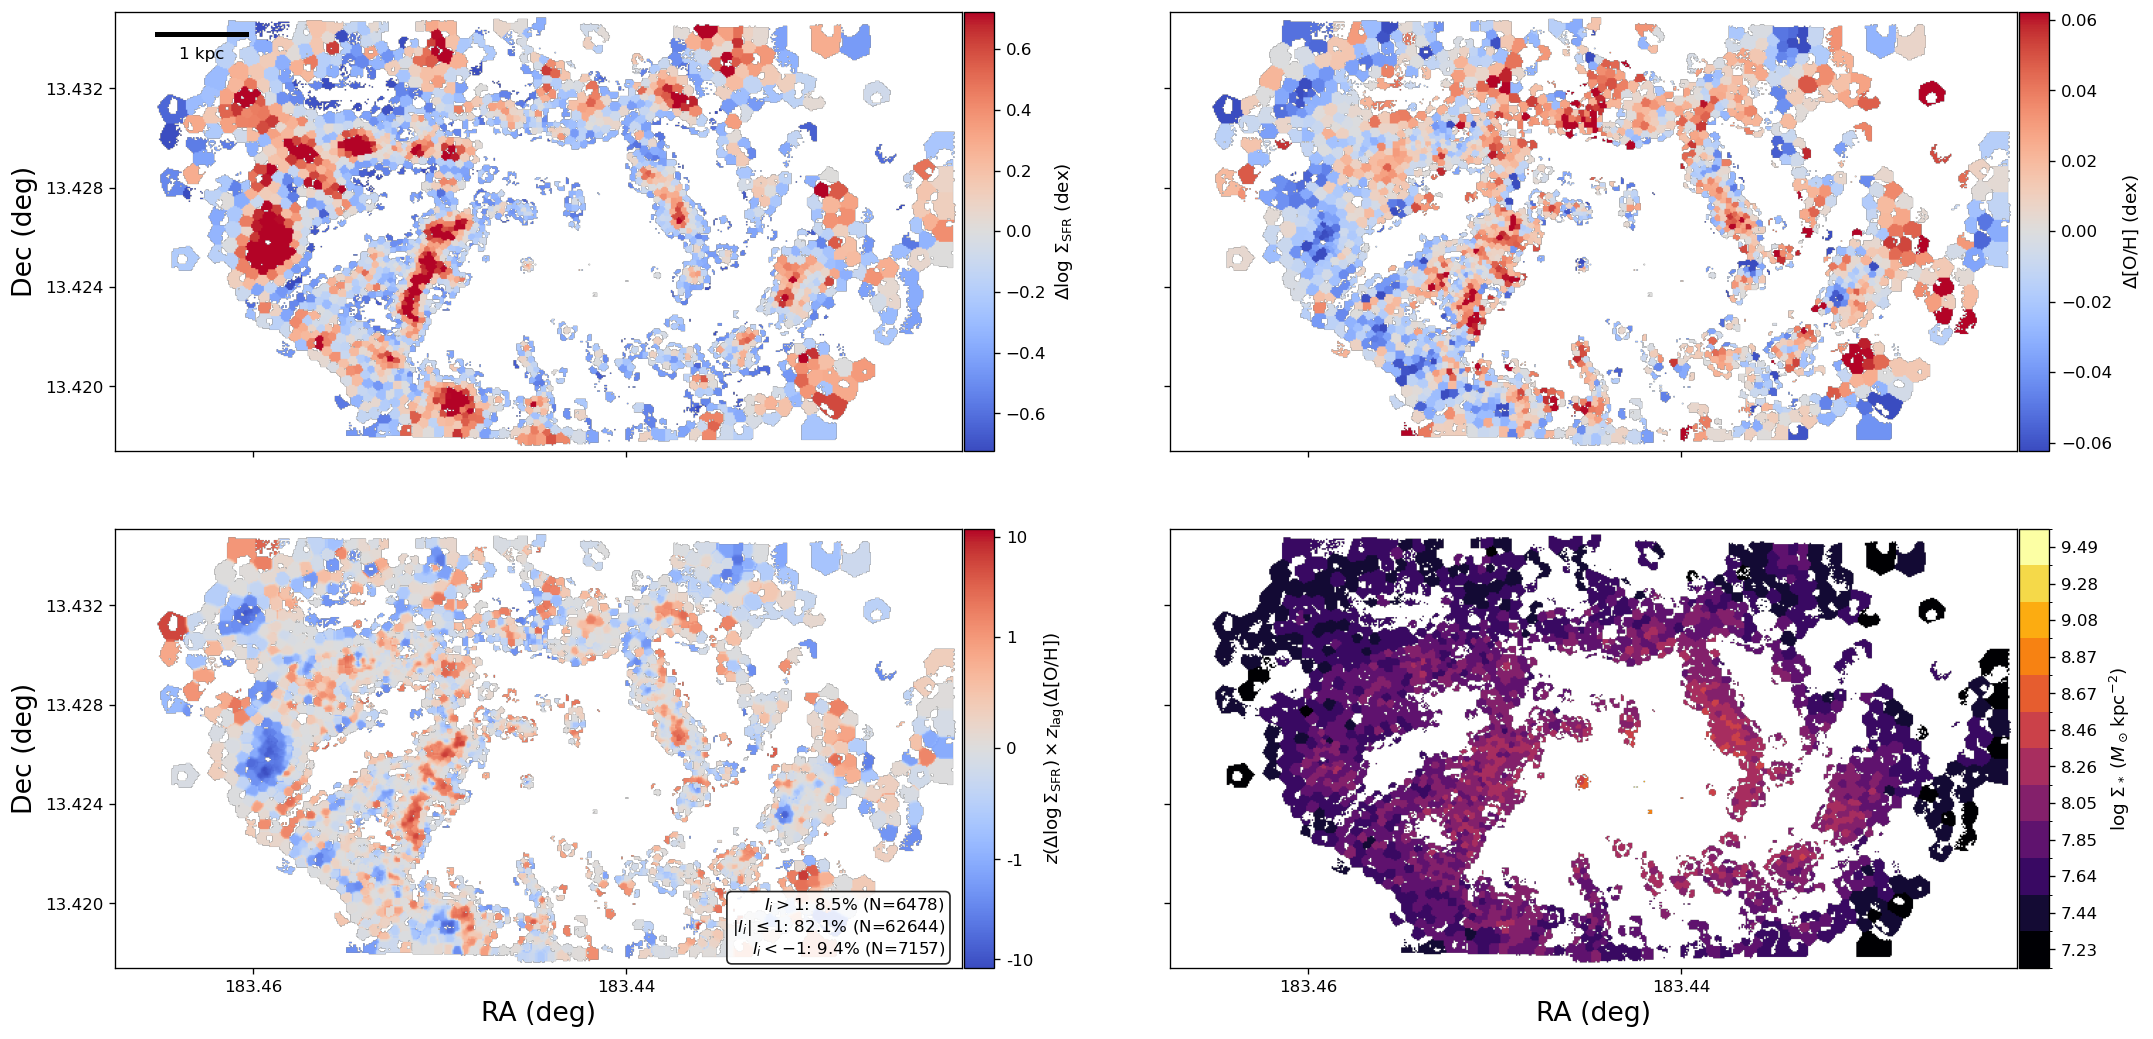

In [3]:
if old_paper_cells_ready(require_ew=True):
    # ------------------------------------------------------------------
    # 2x2 Combined figure: offset maps + Moran-like map + binned Σ* map
    # ------------------------------------------------------------------
    from pathlib import Path
    from astropy.io import fits

    EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
    EW_HDU = 'PROXY_EWHA'
    EW_MIN = 6.0

    from astropy.wcs import WCS
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gs_module
    from matplotlib.colors import BoundaryNorm, SymLogNorm
    import matplotlib.ticker as mticker
    from matplotlib.ticker import ScalarFormatter

    # Only focus on NGC4189 for this visualisation
    galaxies = [gal for gal in ['NGC4189'] if gal in physics_ready_galaxies(require_ew=True)]
    if not galaxies:
        print('Skipped NGC4189 visualisation: nested *_further mass/SFR/OH+EW products are not ready for this galaxy yet.')

    # ------------------------------------------------------------------
    # Define threshold parameter for linear/log colorbar transition and classification
    # ------------------------------------------------------------------
    threshold = 1  # Values between -threshold and +threshold use linear scale

    # ------------------------------------------------------------------
    # 1.  Helper: read the required maps
    # ------------------------------------------------------------------
    def load_maps(gal):
        spatial_path = further_spatial_path(gal)
        gas_path = further_gas_path(gal)
        ew_path = further_ew_path(gal, EW_FILE_SUFFIX)

        if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(ew_path).exists()):
            raise FileNotFoundError(f'Required FITS files for {gal} not found.')

        with fits.open(spatial_path) as h_spatial:
            sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
            wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
        with fits.open(gas_path) as h_gas:
            sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
            ha_sigma_obs = h_gas['HA6562_SIGMA'].data
            ha_sigma_corr = h_gas['HA6562_SIGMA_CORR'].data if 'HA6562_SIGMA_CORR' in h_gas else None
            if ha_sigma_corr is None:
                raise KeyError(f'{gal}: missing HA6562_SIGMA_CORR in {gas_path}')
            if ha_sigma_corr.shape != ha_sigma_obs.shape:
                raise ValueError(f'{gal}: shape mismatch SIGMA_CORR {ha_sigma_corr.shape} vs SIGMA {ha_sigma_obs.shape}')
            sigma2_intrinsic = ha_sigma_obs**2 - ha_sigma_corr**2
            ha_sigma = np.full_like(ha_sigma_obs, np.nan, dtype=float)
            sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
            ha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
            if 'O_H_O3N2_M14_HII' in h_gas:
                oh_map = h_gas['O_H_O3N2_M14_HII'].data
                indicator_name = 'O3N2-M14'
            elif 'O_H_O3N2_M13_HII' in h_gas:
                print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
                oh_map = h_gas['O_H_O3N2_M13_HII'].data
                indicator_name = 'O3N2-M13'
            else:
                available = [hdu.name for hdu in h_gas]
                raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
            gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
        with fits.open(ew_path) as h_ew:
            if EW_HDU not in h_ew:
                raise KeyError(f"Missing {EW_HDU} in {ew_path}")
            ew_ha = h_ew[EW_HDU].data
        ew_ha = align_map_to_shape(ew_ha, sigSFR.shape, label=f"{gal} {EW_HDU}")
        ew_mask = np.isfinite(ew_ha) & (ew_ha > EW_MIN)
        ew_mask = ew_mask & np.isfinite(ha_sigma) & (ha_sigma < 45.0)
        sigSFR = np.where(ew_mask, sigSFR, np.nan)
        oh_map = np.where(ew_mask, oh_map, np.nan)
        return sigM, sigSFR, oh_map, indicator_name, wcs, gas_header

    for gal in galaxies:
        sigM, sigSFR, oh_o3n2_map, indicator_name, wcs_full, gas_header = load_maps(gal)

        # Valid pixels across maps
        valid_sfr = np.isfinite(sigSFR)
        valid_oh = np.isfinite(oh_o3n2_map)
        valid_sigM = np.isfinite(sigM)
        valid_all = valid_sfr & valid_oh & valid_sigM

        # ------------------------------------------------------------------
        # 2.  Calculate offset maps (relative to Σ* bin means)
        # ------------------------------------------------------------------
        # Define 12 Σ* bins
        n_bins = 12
        sigmaM_min = np.nanmin(sigM[valid_all])
        sigmaM_max = np.nanmax(sigM[valid_all])
        sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
        # Initialize offset maps
        sfr_offset = np.full_like(sigSFR, np.nan)
        oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
        # Calculate offset for each Σ* bin
        for i in range(n_bins):
            if i == 0:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
            elif i == n_bins - 1:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
            else:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
            if np.sum(bin_mask) > 0:
                # Calculate bin mean and offset within this bin
                sfr_bin_mean = np.mean(sigSFR[bin_mask])
                oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
                sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
                oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
        sfr_offset_max = np.nanpercentile(np.abs(sfr_offset[valid_all]), 95)
        # Reduce Delta O/H range to 95th percentile to highlight differences
        oh_offset_max = np.nanpercentile(np.abs(oh_offset[valid_all]), 95)
    
        # Global means for display purposes only
        sfr_mean = np.nanmean(sigSFR[valid_sfr])
        oh_mean = np.nanmean(oh_o3n2_map[valid_oh])

        # ------------------------------------------------------------------
        # 3.  Calculate local bivariate Moran-like map
        # ------------------------------------------------------------------
        def local_bivariate_moran(A, B, valid_mask, neighbourhood='queen'):
            """
            Simple Moran-style local bivariate association between A and B.

            Parameters
            ----------
            A, B : 2D arrays
                Maps (e.g. sfr_offset, oh_offset).
            valid_mask : 2D bool
                True where both maps are valid.
            neighbourhood : {'queen', 'rook'}
                'queen' = 8-connected neighbours, 'rook' = 4-connected.

            Returns
            -------
            I_map : 2D array
                Local bivariate Moran-like statistic (sign & amplitude).
            quad_map : 2D int array
                Quadrant type:
                0 = invalid / no neighbours
                1 = high A, high lag(B)
                2 = low A,  high lag(B)
                3 = low A,  low lag(B)
                4 = high A, low lag(B)
            """
            ny, nx = A.shape
            I_map = np.full_like(A, np.nan, dtype=float)
            quad_map = np.zeros_like(A, dtype=int)

            # standardise A,B on valid pixels only
            Aval = A[valid_mask]
            Bval = B[valid_mask]
            Az = (A - np.nanmean(Aval)) / np.nanstd(Aval)
            Bz = (B - np.nanmean(Bval)) / np.nanstd(Bval)

            if neighbourhood == 'queen':
                offsets = [(-1,-1), (-1,0), (-1,1),
                           ( 0,-1),          ( 0,1),
                           ( 1,-1), ( 1,0), ( 1,1)]
            elif neighbourhood == 'rook':
                offsets = [(-1,0), (0,-1), (0,1), (1,0)]
            else:
                raise ValueError("neighbourhood must be 'queen' or 'rook'")

            for i in range(ny):
                for j in range(nx):
                    if not valid_mask[i, j]:
                        continue

                    # collect neighbouring Bz values
                    neigh_vals = []
                    for dy, dx in offsets:
                        ii, jj = i + dy, j + dx
                        if 0 <= ii < ny and 0 <= jj < nx and valid_mask[ii, jj]:
                            neigh_vals.append(Bz[ii, jj])

                    if len(neigh_vals) == 0:
                        continue

                    lag_B = np.mean(neigh_vals)   # spatial lag of B
                    I_val = Az[i, j] * lag_B      # Moran-style product
                    I_map[i, j] = I_val

                    # quadrant classification (like LISA maps)
                    if Az[i, j] >= 0 and lag_B >= 0:
                        quad_map[i, j] = 1  # high A – high B_neigh
                    elif Az[i, j] < 0 and lag_B >= 0:
                        quad_map[i, j] = 2  # low A – high B_neigh
                    elif Az[i, j] < 0 and lag_B < 0:
                        quad_map[i, j] = 3  # low A – low B_neigh
                    else:
                        quad_map[i, j] = 4  # high A – low B_neigh

            return I_map, quad_map

        I_map, quad_map = local_bivariate_moran(sfr_offset, oh_offset, valid_all,
                                                neighbourhood='queen')

        # ------------------------------------------------------------------
        # Calculate statistics for three classes based on threshold
        # ------------------------------------------------------------------
        valid_I = np.isfinite(I_map)
        n_total = np.sum(valid_I)
        n_high = np.sum(I_map[valid_I] > threshold)
        n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
        n_low = np.sum(I_map[valid_I] < -threshold)
        pct_high = (n_high / n_total * 100) if n_total > 0 else 0
        pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
        pct_low = (n_low / n_total * 100) if n_total > 0 else 0

        # ------------------------------------------------------------------
        # 4.  Create binned Σ* map
        # ------------------------------------------------------------------
        sigM_binned_map = np.full_like(sigM, np.nan)
    
        for i in range(n_bins):
            if i == 0:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
            elif i == n_bins - 1:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
            else:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
            # Assign bin center value
            bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
            sigM_binned_map[bin_mask] = bin_center

        # ------------------------------------------------------------------
        # 5.  Prepare coordinate extent
        # ------------------------------------------------------------------
        wcs_celestial = WCS(gas_header).celestial
        y_size, x_size = sigSFR.shape
        x_coords = np.arange(x_size)
        y_coords = np.arange(y_size)
        xx, yy = np.meshgrid(x_coords, y_coords)
        ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
        extent = [ra.max(), ra.min(), dec.min(), dec.max()]

        # ------------------------------------------------------------------
        # 5b.  Scale bar: 5 kpc for 0.2 arcsec/pixel at 16.5 Mpc
        # ------------------------------------------------------------------
        pix_scale_arcsec = 0.2
        distance_mpc = 16.5
        # calculate degrees for 5 kpc, including cos(dec) for the RA axis
        kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
        scalebar_kpc = 1
        scalebar_length_deg = (scalebar_kpc * kpc_arcsec) / 3600.0
        mean_dec = np.nanmean(dec)
        scalebar_length_deg_ra = scalebar_length_deg / np.cos(np.deg2rad(mean_dec))

        def add_scalebar(ax, length_deg, label='1 kpc'):
            x0, x1 = ax.get_xlim()
            x_range = abs(x1 - x0)
            if x_range == 0:
                return
            frac_len = length_deg / x_range
            x_start = 0.05
            y_start = 0.95
            x_end = x_start + frac_len
            line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                            color='k', lw=3, clip_on=False)
            line.set_in_layout(False)
            txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                          transform=ax.transAxes, ha='center', va='top', color='k')
            txt.set_in_layout(False)

        # ------------------------------------------------------------------
        # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
        # ------------------------------------------------------------------
        from mpl_toolkits.axes_grid1 import make_axes_locatable

        # Auto-derive a reasonable figsize from the map extent
        dx = abs(extent[1] - extent[0])   # RA span
        dy = abs(extent[3] - extent[2])   # Dec span
        data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

        panel_h = 4.2   # inches per panel height (tune once)
        panel_w = panel_h * data_ratio
        cbar_w = 0.35   # inches per colorbar (tune once)

        W = 2 * panel_w + 2 * cbar_w + 1.2
        H = 2 * panel_h + 0.8

        fig, axs = plt.subplots(
            2, 2, figsize=(W, H), sharex=True, sharey=True
        )

        # Make space for the appended colorbars (right margin matters)
        fig.subplots_adjust(
            left=0.07, right=0.96, bottom=0.07, top=0.98,
            wspace=0.20, hspace=0.06
        )

        ax1, ax2 = axs[0, 0], axs[0, 1]
        ax3, ax4 = axs[1, 0], axs[1, 1]

        def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size=size, pad=pad)
            cbar = fig.colorbar(im, cax=cax)
            cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
            return cbar

        # --- Ticks / formatting (readable RA, no +1.834e2)
        for ax in (ax1, ax2, ax3, ax4):
            ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
            ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
            ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

        # Hide inner tick labels
        plt.setp(ax1.get_xticklabels(), visible=False)
        plt.setp(ax2.get_xticklabels(), visible=False)
        plt.setp(ax2.get_yticklabels(), visible=False)
        plt.setp(ax4.get_yticklabels(), visible=False)

        # Axis labels (outer only)
        ax3.set_xlabel("RA (deg)", fontsize=16)
        ax4.set_xlabel("RA (deg)", fontsize=16)
        ax1.set_ylabel("Dec (deg)", fontsize=16)
        ax3.set_ylabel("Dec (deg)", fontsize=16)

        # ---- Panel 1: SFR offset
        im_sfr = ax1.imshow(
            np.ma.masked_invalid(sfr_offset),
            origin="lower", cmap="coolwarm",
            extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max,
            aspect="equal"
        )
        add_scalebar(ax1, scalebar_length_deg_ra, label="1 kpc")
        add_cbar(ax1, im_sfr, r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (dex)', labelpad=4)

        # ---- Panel 2: OH offset
        im_oh = ax2.imshow(
            np.ma.masked_invalid(oh_offset),
            origin="lower", cmap="coolwarm",
            extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max,
            aspect="equal"
        )
        add_cbar(ax2, im_oh, r'$\Delta$[O/H] (dex)')

        # ---- Panel 3: Moran-like
        vI = np.nanmax(np.abs(I_map))
        norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

        imI = ax3.imshow(
            np.ma.masked_invalid(I_map),
            origin="lower", cmap="coolwarm",
            extent=extent, norm=norm,
            aspect="equal"
        )
        cbarI = add_cbar(
            ax3, imI,
            r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$'
        )

        # Keep your symmetric-log ticks logic
        max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
        pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
        pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
        neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
        ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
        cbarI.set_ticks(ticks)
        cbarI.set_ticklabels([f"{t:g}" for t in ticks])

        legend_text = (
            rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
            '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
            '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
        )
        ax3.text(
            0.98, 0.02, legend_text, transform=ax3.transAxes,
            fontsize=10, va="bottom", ha="right",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
        )

        # ---- Panel 4: binned Σ*
        cmap_discrete = plt.cm.inferno
        norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

        im_sigM_binned = ax4.imshow(
            np.ma.masked_invalid(sigM_binned_map),
            origin="lower", cmap=cmap_discrete, norm=norm_discrete,
            extent=extent,
            aspect="equal"
        )
        cbar_binned = add_cbar(
            ax4, im_sigM_binned,
            r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$'
        )

        bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
        cbar_binned.set_ticks(bin_centers)
        cbar_binned.set_ticklabels([f"{bc:.2f}" for bc in bin_centers])

        # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran_EW.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
        # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran_EW.pdf', bbox_inches="tight", pad_inches=0.02)
        plt.show()
else:
    print("Skipped copied previous-project analysis cell 8: no nested *_further mass/SFR/OH+EW products are ready yet.")


## Corrected-flux [S II]/[N II] setup

The ratio below uses corrected total flux HDUs and applies only a line-detection gate, not an HII/BPT gate.

In [4]:

from scipy.stats import spearmanr

TARGET_GALAXY = "NGC4189"
SII_NII_SNR_MIN = 3.0
RNG = np.random.default_rng(20260529)

METALLICITY_SPECS = [
    ("O_H_D16_HII", "D16"),
    ("O_H_PG16_HII", "PG16"),
    ("O_H_O3N2_M13_HII", "O3N2-M13"),
    ("O_H_O3N2_C20_HII", "O3N2-C20"),
]


def read_hdu(path: Path, name: str, *, dtype=float, required: bool = True):
    with fits.open(path, memmap=True) as hdul:
        names = {hdu.name.upper(): hdu.name for hdu in hdul}
        exact = names.get(name.upper())
        if exact is None:
            if required:
                raise KeyError(f"Missing HDU {name} in {path}")
            return None
        data = hdul[exact].data
        if data is None:
            if required:
                raise ValueError(f"HDU {name} has no data in {path}")
            return None
        return np.asarray(data, dtype=dtype)


def finite_percentile_limits(data, qlo=2, qhi=98):
    vals = np.asarray(data, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return None, None
    return tuple(np.nanpercentile(vals, [qlo, qhi]))


def corrected_sii_nii_maps(galaxy: str, *, snr_min: float = SII_NII_SNR_MIN):
    """Corrected total-flux SII/NII map. Detection-gated, but not BPT/HII-gated."""
    gas_path = further_gas_path(galaxy)
    with fits.open(gas_path, memmap=True) as h:
        nii = np.asarray(h["NII6583_FLUX_CORR"].data, dtype=float)
        nii_err = np.asarray(h["NII6583_FLUX_ERR_CORR"].data, dtype=float)
        sii6716 = np.asarray(h["SII6716_FLUX_CORR"].data, dtype=float)
        sii6716_err = np.asarray(h["SII6716_FLUX_ERR_CORR"].data, dtype=float)
        sii6730 = np.asarray(h["SII6730_FLUX_CORR"].data, dtype=float)
        sii6730_err = np.asarray(h["SII6730_FLUX_ERR_CORR"].data, dtype=float)
        ha = np.asarray(h["HA6562_FLUX_CORR"].data, dtype=float)

    sii = sii6716 + sii6730
    sii_err = np.hypot(sii6716_err, sii6730_err)
    ok = (
        np.isfinite(nii) & np.isfinite(nii_err) & (nii > 0) & (nii_err > 0) &
        np.isfinite(sii) & np.isfinite(sii_err) & (sii > 0) & (sii_err > 0) &
        (nii / nii_err >= snr_min) &
        (sii / sii_err >= snr_min)
    )

    ratio = np.full_like(nii, np.nan, dtype=float)
    log_ratio = np.full_like(nii, np.nan, dtype=float)
    ratio[ok] = sii[ok] / nii[ok]
    log_ratio[ok] = np.log10(ratio[ok])

    sii_ha = np.full_like(nii, np.nan, dtype=float)
    nii_ha = np.full_like(nii, np.nan, dtype=float)
    log_sii_ha = np.full_like(nii, np.nan, dtype=float)
    log_nii_ha = np.full_like(nii, np.nan, dtype=float)
    ha_ok = ok & np.isfinite(ha) & (ha > 0)
    sii_ha[ha_ok] = sii[ha_ok] / ha[ha_ok]
    nii_ha[ha_ok] = nii[ha_ok] / ha[ha_ok]
    log_sii_ha[ha_ok] = np.log10(sii_ha[ha_ok])
    log_nii_ha[ha_ok] = np.log10(nii_ha[ha_ok])

    return {
        "ratio": ratio,
        "log_ratio": log_ratio,
        "sii_ha": sii_ha,
        "nii_ha": nii_ha,
        "log_sii_ha": log_sii_ha,
        "log_nii_ha": log_nii_ha,
        "valid": ok,
    }


def load_moran_inputs_with_s2n2(galaxy: str):
    spatial_path = further_spatial_path(galaxy)
    gas_path = further_gas_path(galaxy)
    ew_path = further_ew_path(galaxy, "_proxy_EW_maps.fits")

    with fits.open(spatial_path, memmap=True) as h_spatial:
        sigM = np.asarray(h_spatial["LOGMASS_SURFACE_DENSITY"].data, dtype=float)
    with fits.open(gas_path, memmap=True) as h_gas:
        sigSFR = np.asarray(h_gas["LOGSFR_SURFACE_DENSITY_HII"].data, dtype=float)
        oh_map = np.asarray(h_gas["O_H_O3N2_M13_HII"].data, dtype=float)
        ha_sigma = intrinsic_sigma_from_maps(
            h_gas["HA6562_SIGMA"].data,
            h_gas["HA6562_SIGMA_CORR"].data,
            label=f"{galaxy} HA6562",
        )
        gas_header = h_gas["LOGSFR_SURFACE_DENSITY_HII"].header
    with fits.open(ew_path, memmap=True) as h_ew:
        ew_ha = np.asarray(h_ew["PROXY_EWHA"].data, dtype=float)

    ew_ha = align_map_to_shape(ew_ha, sigSFR.shape, label=f"{galaxy} PROXY_EWHA")
    ew_mask = np.isfinite(ew_ha) & (ew_ha > 6.0) & np.isfinite(ha_sigma) & (ha_sigma < 45.0)
    sigSFR = np.where(ew_mask, sigSFR, np.nan)
    oh_map = np.where(ew_mask, oh_map, np.nan)

    ratio_maps = corrected_sii_nii_maps(galaxy)
    sii_nii = align_map_to_shape(ratio_maps["ratio"], sigSFR.shape, label=f"{galaxy} SII/NII")

    return sigM, sigSFR, oh_map, sii_nii, gas_header


def local_bivariate_moran(A, B, valid_mask, neighbourhood="queen"):
    ny, nx = A.shape
    I_map = np.full_like(A, np.nan, dtype=float)
    quad_map = np.zeros_like(A, dtype=int)
    Aval = A[valid_mask]
    Bval = B[valid_mask]
    Az = (A - np.nanmean(Aval)) / np.nanstd(Aval)
    Bz = (B - np.nanmean(Bval)) / np.nanstd(Bval)
    if neighbourhood == "queen":
        offsets = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]
    elif neighbourhood == "rook":
        offsets = [(-1, 0), (0, -1), (0, 1), (1, 0)]
    else:
        raise ValueError("neighbourhood must be 'queen' or 'rook'")

    for i in range(ny):
        for j in range(nx):
            if not valid_mask[i, j]:
                continue
            vals = []
            for dy, dx in offsets:
                ii, jj = i + dy, j + dx
                if 0 <= ii < ny and 0 <= jj < nx and valid_mask[ii, jj]:
                    vals.append(Bz[ii, jj])
            if not vals:
                continue
            lag_B = np.mean(vals)
            I_map[i, j] = Az[i, j] * lag_B
            if Az[i, j] >= 0 and lag_B >= 0:
                quad_map[i, j] = 1
            elif Az[i, j] < 0 and lag_B >= 0:
                quad_map[i, j] = 2
            elif Az[i, j] < 0 and lag_B < 0:
                quad_map[i, j] = 3
            else:
                quad_map[i, j] = 4
    return I_map, quad_map


ratio_maps = corrected_sii_nii_maps(TARGET_GALAXY)
print(
    f"{TARGET_GALAXY}: corrected total-flux SII/NII pixels with S/N >= {SII_NII_SNR_MIN:g}: "
    f"{np.isfinite(ratio_maps['ratio']).sum():,}"
)
print("SII/NII linear limits:", finite_percentile_limits(ratio_maps["ratio"], 1, 99))


NGC4189: corrected total-flux SII/NII pixels with S/N >= 3: 159,160
SII/NII linear limits: (np.float64(0.6990170320810926), np.float64(2.0727170990206973))


## Moran-map variant with [S II]/[N II]

This repeats the NGC4189 2x2 map logic, but changes the bottom-right panel from binned stellar-mass surface density to corrected-flux `log10([SII]/[NII])`.

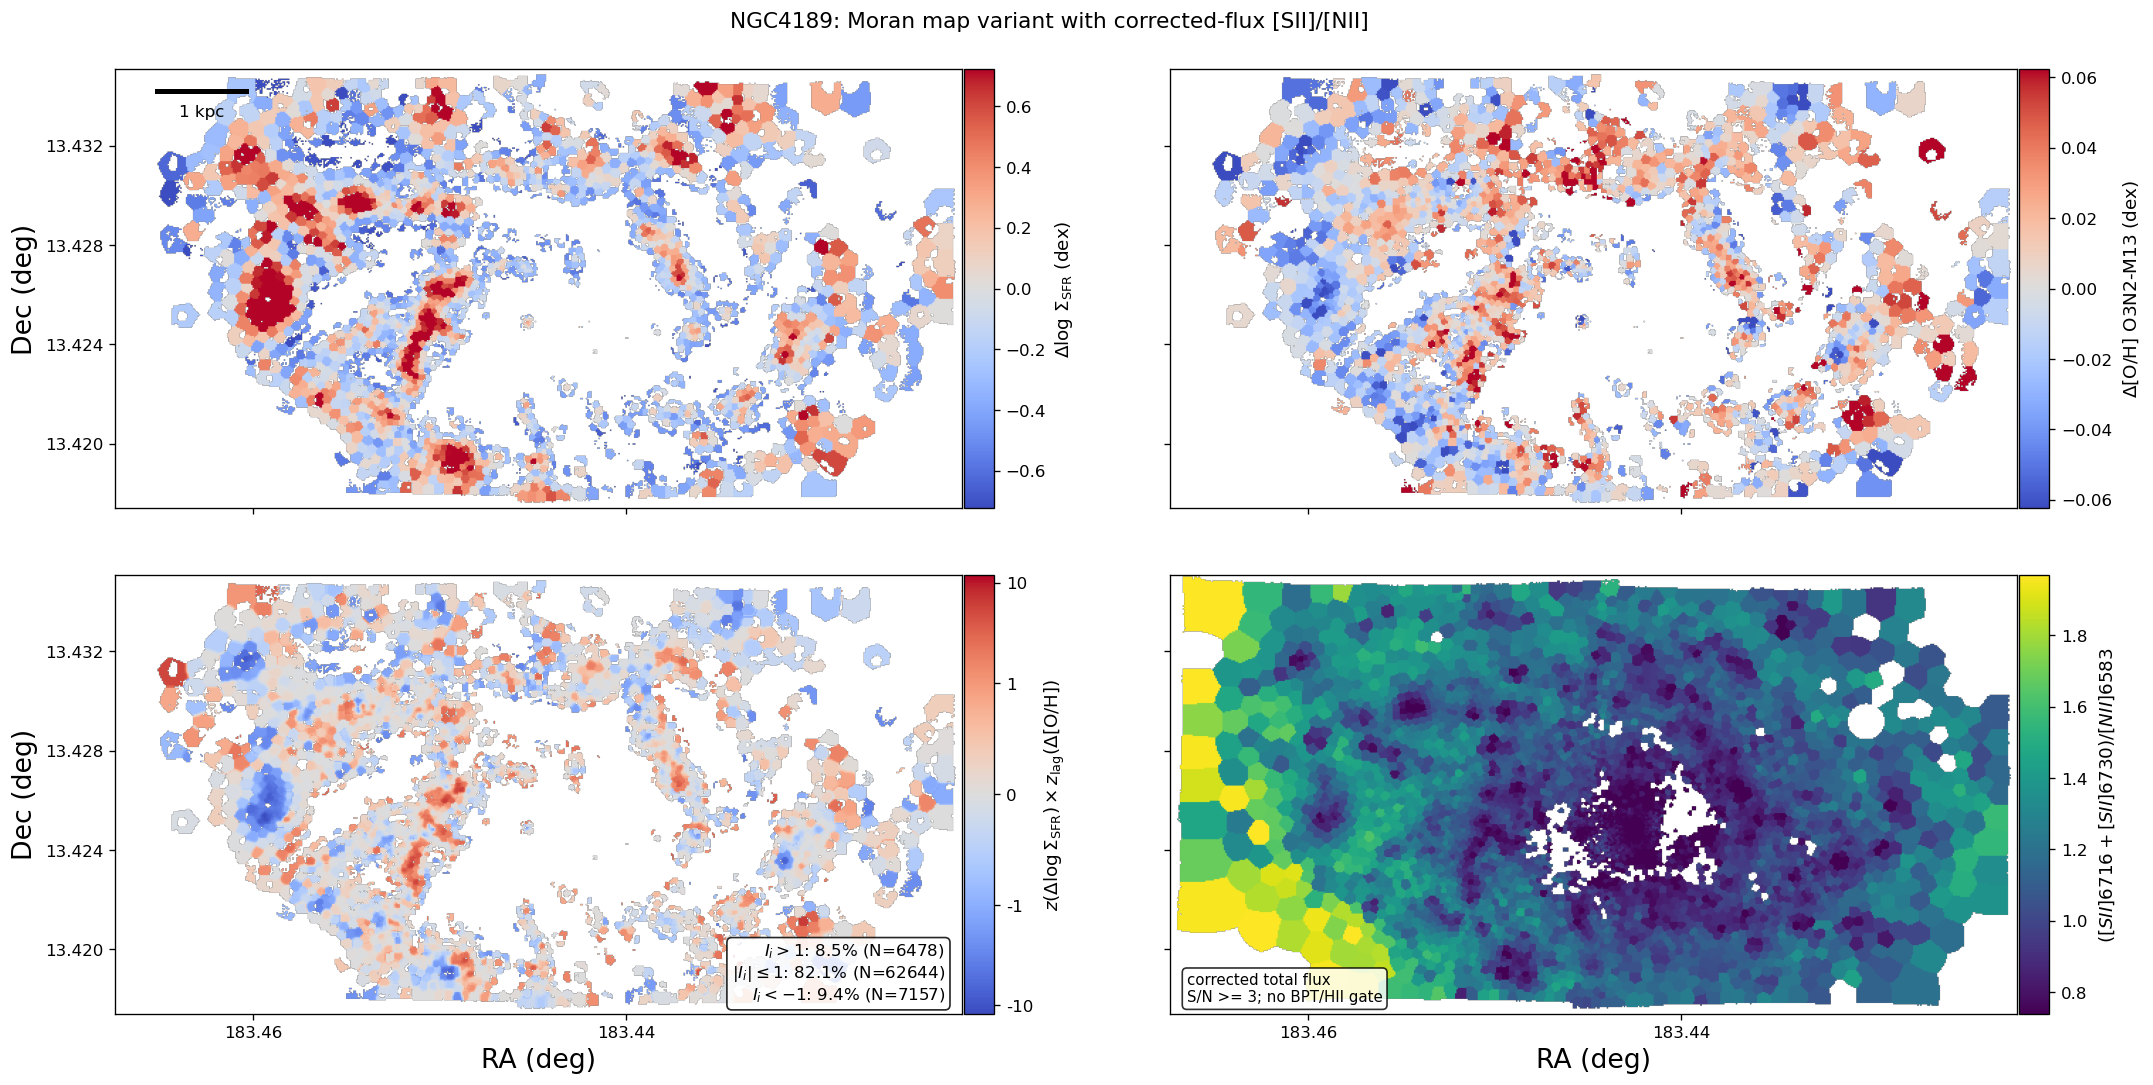

In [5]:

from matplotlib.colors import SymLogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable


def plot_moran_s2n2_variant(galaxy: str = TARGET_GALAXY, threshold: float = 1.0):
    sigM, sigSFR, oh_map, sii_nii, gas_header = load_moran_inputs_with_s2n2(galaxy)
    valid_all = np.isfinite(sigM) & np.isfinite(sigSFR) & np.isfinite(oh_map)

    n_bins = 12
    sigmaM_bin_edges = np.linspace(np.nanmin(sigM[valid_all]), np.nanmax(sigM[valid_all]), n_bins + 1)
    sfr_offset = np.full_like(sigSFR, np.nan)
    oh_offset = np.full_like(oh_map, np.nan)
    for i in range(n_bins):
        if i == n_bins - 1:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i + 1]) & valid_all
        else:
            bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i + 1]) & valid_all
        if np.any(bin_mask):
            sfr_offset[bin_mask] = sigSFR[bin_mask] - np.nanmean(sigSFR[bin_mask])
            oh_offset[bin_mask] = oh_map[bin_mask] - np.nanmean(oh_map[bin_mask])

    sfr_offset_max = np.nanpercentile(np.abs(sfr_offset[valid_all]), 95)
    oh_offset_max = np.nanpercentile(np.abs(oh_offset[valid_all]), 95)
    I_map, _ = local_bivariate_moran(sfr_offset, oh_offset, valid_all, neighbourhood="queen")

    valid_I = np.isfinite(I_map)
    n_total = np.sum(valid_I)
    n_high = np.sum(I_map[valid_I] > threshold)
    n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
    n_low = np.sum(I_map[valid_I] < -threshold)
    pct_high = (n_high / n_total * 100) if n_total else 0
    pct_mid = (n_mid / n_total * 100) if n_total else 0
    pct_low = (n_low / n_total * 100) if n_total else 0

    wcs_celestial = WCS(gas_header).celestial
    y_size, x_size = sigSFR.shape
    xx, yy = np.meshgrid(np.arange(x_size), np.arange(y_size))
    ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
    extent = [ra.max(), ra.min(), dec.min(), dec.max()]

    pix_scale_arcsec = 0.2
    distance_mpc = 16.5
    scalebar_kpc = 1
    scalebar_length_deg = (scalebar_kpc * 206265.0 / (distance_mpc * 1000.0)) / 3600.0
    scalebar_length_deg_ra = scalebar_length_deg / np.cos(np.deg2rad(np.nanmean(dec)))

    dx = abs(extent[1] - extent[0])
    dy = abs(extent[3] - extent[2])
    data_ratio = (dx / dy) if dy > 0 else 1.0
    panel_h = 4.2
    panel_w = panel_h * data_ratio
    fig, axs = plt.subplots(2, 2, figsize=(2 * panel_w + 1.9, 2 * panel_h + 0.8), sharex=True, sharey=True)
    fig.subplots_adjust(left=0.07, right=0.96, bottom=0.07, top=0.96, wspace=0.20, hspace=0.06)

    ax1, ax2 = axs[0, 0], axs[0, 1]
    ax3, ax4 = axs[1, 0], axs[1, 1]

    def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size=size, pad=pad)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
        return cbar

    def add_scalebar(ax, length_deg, label="1 kpc"):
        x0, x1 = ax.get_xlim()
        frac_len = length_deg / abs(x1 - x0)
        line, = ax.plot([0.05, 0.05 + frac_len], [0.95, 0.95], transform=ax.transAxes, color="k", lw=3, clip_on=False)
        line.set_in_layout(False)
        txt = ax.text(0.05 + frac_len / 2, 0.92, label, transform=ax.transAxes, ha="center", va="top", color="k")
        txt.set_in_layout(False)

    for ax in (ax1, ax2, ax3, ax4):
        ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
        ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
        ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax2.get_yticklabels(), visible=False)
    plt.setp(ax4.get_yticklabels(), visible=False)
    ax3.set_xlabel("RA (deg)", fontsize=16)
    ax4.set_xlabel("RA (deg)", fontsize=16)
    ax1.set_ylabel("Dec (deg)", fontsize=16)
    ax3.set_ylabel("Dec (deg)", fontsize=16)

    im_sfr = ax1.imshow(np.ma.masked_invalid(sfr_offset), origin="lower", cmap="coolwarm", extent=extent,
                        vmin=-sfr_offset_max, vmax=sfr_offset_max, aspect="equal")
    add_scalebar(ax1, scalebar_length_deg_ra)
    add_cbar(ax1, im_sfr, r"$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (dex)", labelpad=4)

    im_oh = ax2.imshow(np.ma.masked_invalid(oh_offset), origin="lower", cmap="coolwarm", extent=extent,
                       vmin=-oh_offset_max, vmax=oh_offset_max, aspect="equal")
    add_cbar(ax2, im_oh, r"$\Delta$[O/H] O3N2-M13 (dex)")

    vI = np.nanmax(np.abs(I_map))
    norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)
    imI = ax3.imshow(np.ma.masked_invalid(I_map), origin="lower", cmap="coolwarm", extent=extent, norm=norm, aspect="equal")
    cbarI = add_cbar(ax3, imI, r"$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$")
    max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
    pos_ticks = [10 ** k for k in range(0, max_pow + 1) if 10 ** k <= vI]
    ticks = sorted(set([-p for p in reversed([p for p in pos_ticks if p != threshold])] + [-threshold, 0.0, threshold] + [p for p in pos_ticks if p != threshold]))
    cbarI.set_ticks(ticks)
    cbarI.set_ticklabels([f"{t:g}" for t in ticks])
    ax3.text(
        0.98, 0.02,
        rf"$I_i > {threshold:g}$: {pct_high:.1f}% (N={n_high})" + "\n" +
        rf"$|I_i| \leq {threshold:g}$: {pct_mid:.1f}% (N={n_mid})" + "\n" +
        rf"$I_i < -{threshold:g}$: {pct_low:.1f}% (N={n_low})",
        transform=ax3.transAxes, fontsize=10, va="bottom", ha="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
    )

    s2n2_vmin, s2n2_vmax = finite_percentile_limits(sii_nii, 2, 98)
    im_s2n2 = ax4.imshow(np.ma.masked_invalid(sii_nii), origin="lower", cmap="viridis", extent=extent,
                         vmin=s2n2_vmin, vmax=s2n2_vmax, aspect="equal")
    add_cbar(ax4, im_s2n2, r"$([SII]6716+[SII]6730)/[NII]6583$")
    ax4.text(
        0.02, 0.02,
        f"corrected total flux\nS/N >= {SII_NII_SNR_MIN:g}; no BPT/HII gate",
        transform=ax4.transAxes, fontsize=9, va="bottom", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.82),
    )

    fig.suptitle(f"{galaxy}: Moran map variant with corrected-flux [SII]/[NII]", y=0.995, fontsize=13)
    # fig.savefig(OUTDIR / f"{galaxy}_correlation_map_moran_SII_NII.png", dpi=300, bbox_inches="tight", pad_inches=0.02)
    plt.show()
    return fig


fig = plot_moran_s2n2_variant(TARGET_GALAXY)


## Four metallicity calibrations versus [S II]/[N II]

These use the existing HII metallicity HDUs for D16, PG16, O3N2-M13, and O3N2-C20. The x-axis ratio itself is computed from corrected total fluxes before overlap with finite metallicity pixels.

Metallicity/SII-NII overlap rows: 399,392


method
D16         99848
O3N2-C20    99848
O3N2-M13    99848
PG16        99848
Name: pixels, dtype: int64

,method,n,"rho(SII/NII, O/H)",p_raw,"rho(SII/NII, O/H residual at fixed Sigma*)",p_residual,SII/NII_p16,SII/NII_p50,SII/NII_p84
0,D16,99848,-0.9752,0.0,-0.7764,0.0,0.9345,1.1346,1.3599
1,PG16,99848,-0.6753,0.0,-0.4455,0.0,0.9345,1.1346,1.3599
2,O3N2-M13,99848,-0.2696,0.0,-0.1100,0.0,0.9345,1.1346,1.3599
3,O3N2-C20,99848,-0.2696,0.0,-0.1098,0.0,0.9345,1.1346,1.3599


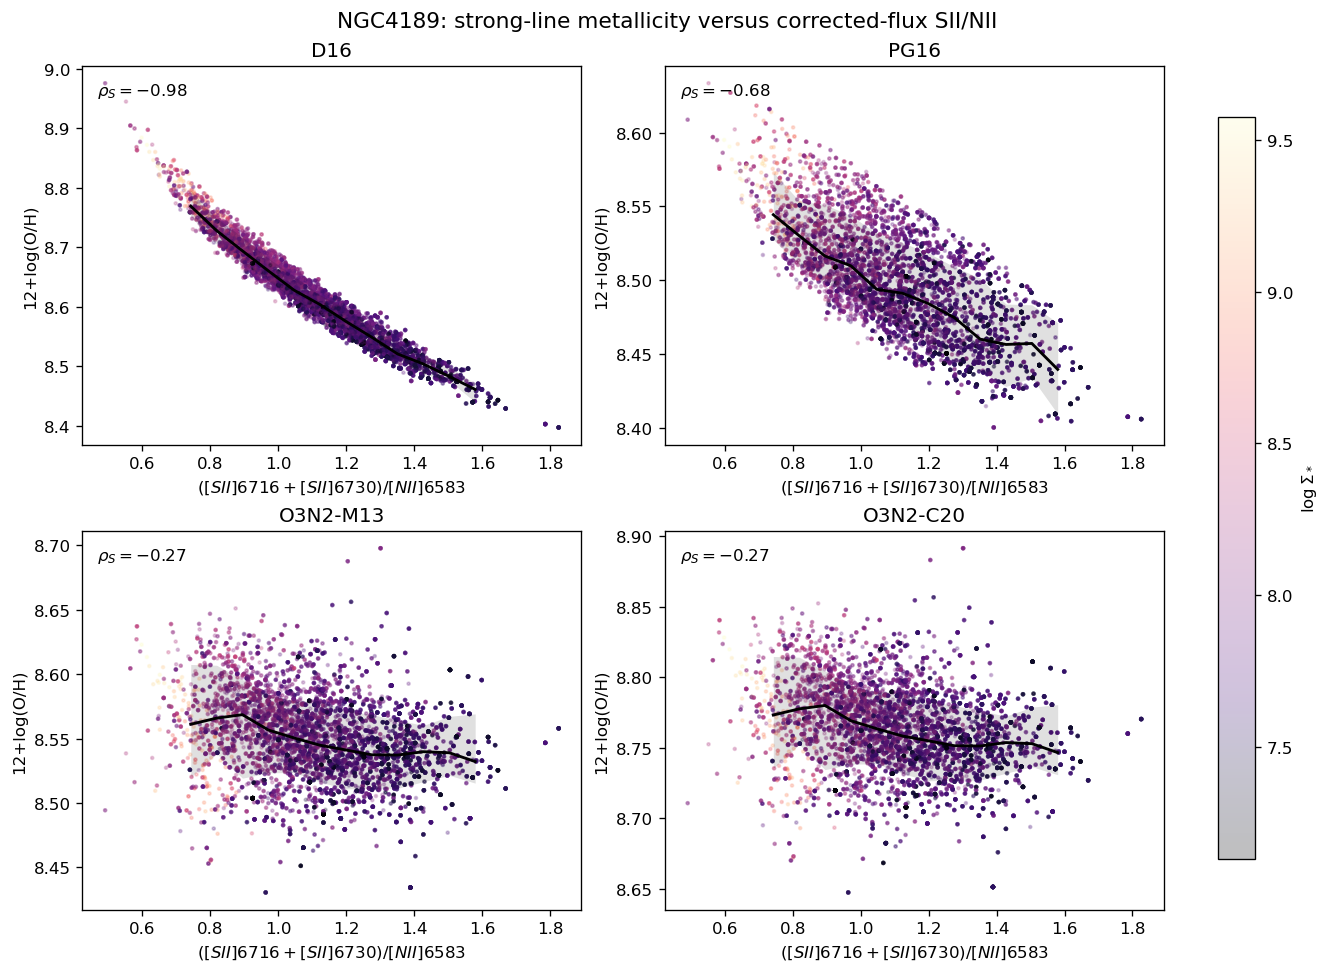

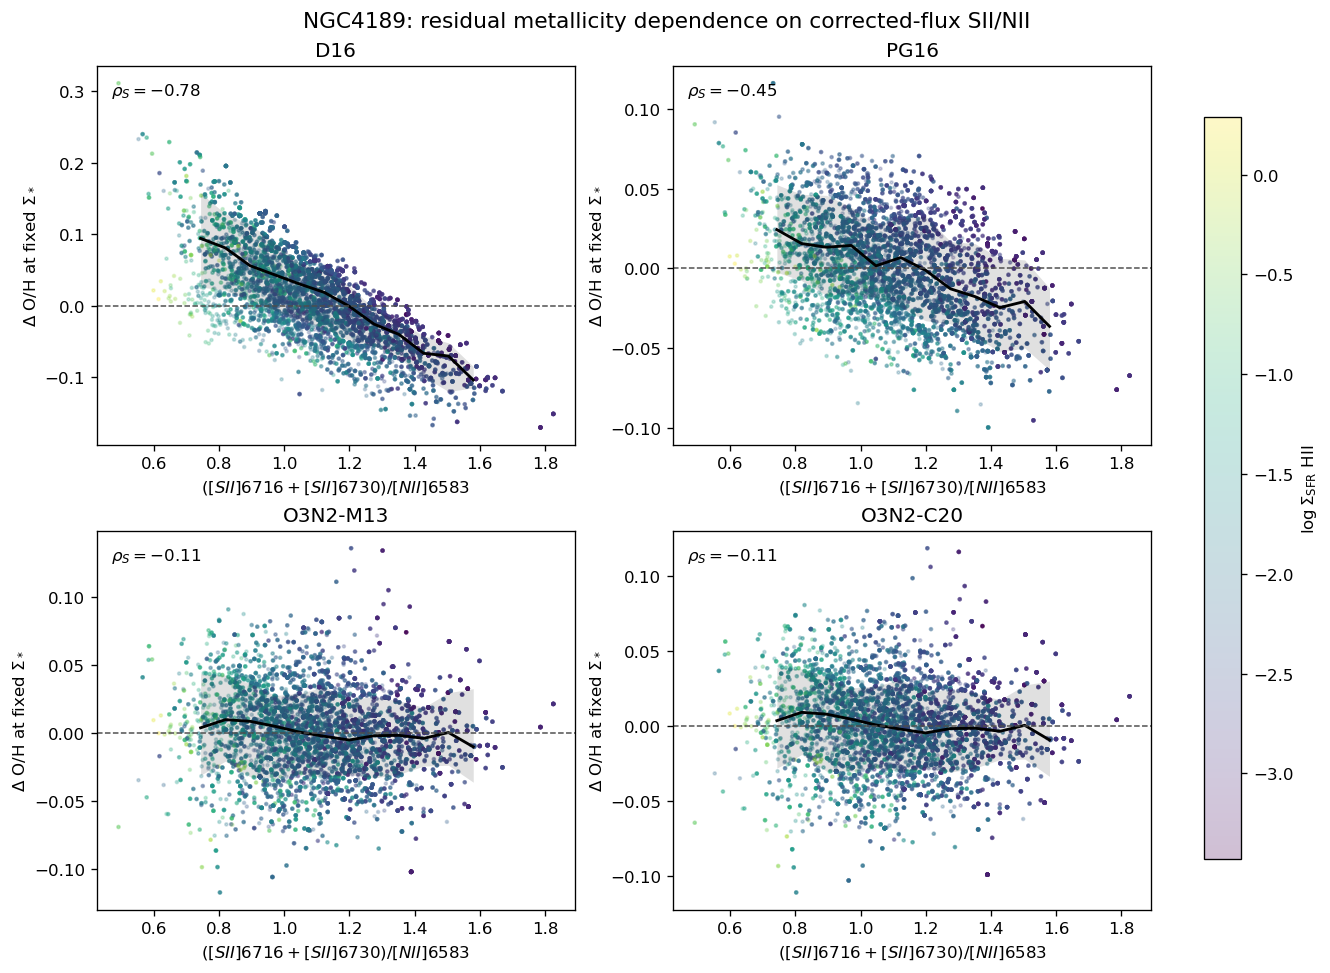

In [6]:

def residual_by_mass_bins(mass, y, valid, *, n_bins=12):
    residual = np.full_like(y, np.nan, dtype=float)
    if np.sum(valid) == 0:
        return residual
    edges = np.linspace(np.nanmin(mass[valid]), np.nanmax(mass[valid]), n_bins + 1)
    for i in range(n_bins):
        if i == n_bins - 1:
            in_bin = valid & (mass >= edges[i]) & (mass <= edges[i + 1])
        else:
            in_bin = valid & (mass >= edges[i]) & (mass < edges[i + 1])
        if np.sum(in_bin) >= 10:
            residual[in_bin] = y[in_bin] - np.nanmedian(y[in_bin])
    return residual


def binned_median_track(x, y, *, nbins=12, min_count=20):
    finite = np.isfinite(x) & np.isfinite(y)
    if np.sum(finite) < min_count:
        return np.array([]), np.array([]), np.array([]), np.array([])
    edges = np.linspace(np.nanpercentile(x[finite], 1), np.nanpercentile(x[finite], 99), nbins + 1)
    centers, medians, lo, hi = [], [], [], []
    for start, end in zip(edges[:-1], edges[1:]):
        ok = finite & (x >= start) & (x < end)
        if np.sum(ok) < min_count:
            continue
        centers.append((start + end) / 2)
        medians.append(np.nanmedian(y[ok]))
        lo.append(np.nanpercentile(y[ok], 16))
        hi.append(np.nanpercentile(y[ok], 84))
    return map(np.asarray, (centers, medians, lo, hi))


def collect_metallicity_s2n2_points(galaxy: str = TARGET_GALAXY):
    gas_path = further_gas_path(galaxy)
    spatial_path = further_spatial_path(galaxy)
    sii_nii = corrected_sii_nii_maps(galaxy)["ratio"]
    mass = read_hdu(spatial_path, "LOGMASS_SURFACE_DENSITY")
    logsfr = read_hdu(gas_path, "LOGSFR_SURFACE_DENSITY_HII")
    frames = []

    for hdu_name, label in METALLICITY_SPECS:
        oh = read_hdu(gas_path, hdu_name)
        sii_nii_here = align_map_to_shape(sii_nii, oh.shape, label=f"{galaxy} SII/NII for {label}")
        mass_here = align_map_to_shape(mass, oh.shape, label=f"{galaxy} mass for {label}")
        logsfr_here = align_map_to_shape(logsfr, oh.shape, label=f"{galaxy} logsfr for {label}")
        ok = np.isfinite(sii_nii_here) & np.isfinite(oh) & np.isfinite(mass_here)
        residual = residual_by_mass_bins(mass_here, oh, ok, n_bins=12)
        ok = ok & np.isfinite(residual)
        if not np.any(ok):
            continue
        frames.append(pd.DataFrame({
            "galaxy": galaxy,
            "method": label,
            "hdu": hdu_name,
            "sii_nii": sii_nii_here[ok],
            "oh": oh[ok],
            "oh_resid_massbin": residual[ok],
            "logmass_surface_density": mass_here[ok],
            "logsfr_surface_density_hii": logsfr_here[ok],
        }))

    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


METALLICITY_S2N2_POINTS = collect_metallicity_s2n2_points(TARGET_GALAXY)
print(f"Metallicity/SII-NII overlap rows: {len(METALLICITY_S2N2_POINTS):,}")
display(METALLICITY_S2N2_POINTS.groupby("method").size().rename("pixels"))

summary_rows = []
for method, group in METALLICITY_S2N2_POINTS.groupby("method", sort=False):
    rho_raw, p_raw = spearmanr(group["sii_nii"], group["oh"], nan_policy="omit")
    rho_res, p_res = spearmanr(group["sii_nii"], group["oh_resid_massbin"], nan_policy="omit")
    summary_rows.append({
        "method": method,
        "n": len(group),
        "rho(SII/NII, O/H)": rho_raw,
        "p_raw": p_raw,
        "rho(SII/NII, O/H residual at fixed Sigma*)": rho_res,
        "p_residual": p_res,
        "SII/NII_p16": np.nanpercentile(group["sii_nii"], 16),
        "SII/NII_p50": np.nanpercentile(group["sii_nii"], 50),
        "SII/NII_p84": np.nanpercentile(group["sii_nii"], 84),
    })
S2N2_CORRELATION_SUMMARY = pd.DataFrame(summary_rows)
display(S2N2_CORRELATION_SUMMARY.round(4))


def scatter_sample(frame, max_points=12000):
    if len(frame) <= max_points:
        return frame
    return frame.sample(n=max_points, random_state=20260529)


fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
axes = axes.ravel()
for ax, (method, group) in zip(axes, METALLICITY_S2N2_POINTS.groupby("method", sort=False)):
    sample = scatter_sample(group)
    sc = ax.scatter(
        sample["sii_nii"], sample["oh"], c=sample["logmass_surface_density"],
        s=3, alpha=0.25, cmap="magma", rasterized=True,
    )
    centers, med, lo, hi = binned_median_track(group["sii_nii"].to_numpy(), group["oh"].to_numpy())
    if len(centers):
        ax.plot(centers, med, color="black", lw=1.7)
        ax.fill_between(centers, lo, hi, color="black", alpha=0.12, lw=0)
    rho = S2N2_CORRELATION_SUMMARY.loc[S2N2_CORRELATION_SUMMARY["method"] == method, "rho(SII/NII, O/H)"].iloc[0]
    ax.text(0.03, 0.96, rf"$\rho_S={rho:.2f}$", transform=ax.transAxes, ha="left", va="top")
    ax.set_title(method)
    ax.set_xlabel(r"$([SII]6716+[SII]6730)/[NII]6583$")
    ax.set_ylabel(r"12+log(O/H)")
fig.colorbar(sc, ax=axes.tolist(), label=r"$\log\Sigma_*$", shrink=0.88)
fig.suptitle(f"{TARGET_GALAXY}: strong-line metallicity versus corrected-flux SII/NII", fontsize=13)
# fig.savefig(OUTDIR / f"{TARGET_GALAXY}_metallicity_vs_SII_NII.png", dpi=300, bbox_inches="tight")
plt.show()


fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
axes = axes.ravel()
for ax, (method, group) in zip(axes, METALLICITY_S2N2_POINTS.groupby("method", sort=False)):
    sample = scatter_sample(group)
    sc = ax.scatter(
        sample["sii_nii"], sample["oh_resid_massbin"], c=sample["logsfr_surface_density_hii"],
        s=3, alpha=0.25, cmap="viridis", rasterized=True,
    )
    centers, med, lo, hi = binned_median_track(group["sii_nii"].to_numpy(), group["oh_resid_massbin"].to_numpy())
    if len(centers):
        ax.plot(centers, med, color="black", lw=1.7)
        ax.fill_between(centers, lo, hi, color="black", alpha=0.12, lw=0)
    rho = S2N2_CORRELATION_SUMMARY.loc[
        S2N2_CORRELATION_SUMMARY["method"] == method,
        "rho(SII/NII, O/H residual at fixed Sigma*)",
    ].iloc[0]
    ax.axhline(0, color="0.3", lw=0.9, ls="--")
    ax.text(0.03, 0.96, rf"$\rho_S={rho:.2f}$", transform=ax.transAxes, ha="left", va="top")
    ax.set_title(method)
    ax.set_xlabel(r"$([SII]6716+[SII]6730)/[NII]6583$")
    ax.set_ylabel(r"$\Delta$ O/H at fixed $\Sigma_*$")
fig.colorbar(sc, ax=axes.tolist(), label=r"$\log\Sigma_{\rm SFR}$ HII", shrink=0.88)
fig.suptitle(f"{TARGET_GALAXY}: residual metallicity dependence on corrected-flux SII/NII", fontsize=13)
# fig.savefig(OUTDIR / f"{TARGET_GALAXY}_metallicity_residual_vs_SII_NII.png", dpi=300, bbox_inches="tight")
plt.show()


## Practical next diagnostics

The two residual panels are the most relevant checks for the science question: they ask whether the metallicity maps still vary with S2N2 after subtracting the median O/H at fixed stellar-mass surface density.

Useful follow-ups if the residual trend is strong:

- repeat the residual plot versus `log([SII]/Halpha)` and `log([NII]/Halpha)` separately, because S2N2 can hide whether the driver is enhanced sulfur, enhanced nitrogen, or both;
- compare HII-gated versus SF-gated metallicity maps, because the S2N2 map itself is not BPT-gated;
- color the residual plot by `NII_BPT`/`SII_BPT` or Halpha surface brightness to separate DIG/LIER-like leakage from abundance-pattern effects;
- once SIII9068 is available, replace this proxy with the cleaner same-element ionization axis `log([SII]/[SIII])`.


## Current product readiness

`Raw gas QC-ready` means a galaxy has enough basic spatial and gas products to make low-level QC plots. `SFH QC-ready` means it also has the SFH map product. `Previous-paper physics-map ready` is the stricter science set used below: mass surface density, HII/SF SFR maps, and O3N2-M13 metallicity maps are present in the preferred local products.

The all-galaxy science cells below use only the 17 physics-map-ready galaxies.

In [7]:

SCIENCE_READY_GALAXIES = list(READY_PHYSICS_GALAXIES)
QC_NOT_SCIENCE_GALAXIES = sorted(set(RAW_GAS_GALAXIES) - set(SCIENCE_READY_GALAXIES))

print(f"Raw gas QC-ready galaxies: {len(RAW_GAS_GALAXIES)}")
print(f"SFH QC-ready galaxies: {len(SFH_GALAXIES)}")
print(f"Previous-paper physics-map ready galaxies: {len(SCIENCE_READY_GALAXIES)}")
print("QC-ready but not science-ready:", ", ".join(QC_NOT_SCIENCE_GALAXIES) if QC_NOT_SCIENCE_GALAXIES else "none")

readiness_cols = [
    "has_spatial",
    "has_gas",
    "has_sfh",
    "has_spatial_further",
    "has_gas_further",
    "has_mass_map",
    "has_sfr_map",
    "has_o3n2_m13",
    "has_proxy_ew",
    "ready_raw_gas_qc",
    "ready_sfh_qc",
    "ready_physics_maps",
]
display(PRODUCTS.loc[QC_NOT_SCIENCE_GALAXIES + SCIENCE_READY_GALAXIES, readiness_cols])


Raw gas QC-ready galaxies: 20
SFH QC-ready galaxies: 20
Previous-paper physics-map ready galaxies: 18
QC-ready but not science-ready: NGC4383, NGC4388


,has_spatial,has_gas,has_sfh,has_spatial_further,has_gas_further,has_mass_map,has_sfr_map,has_o3n2_m13,has_proxy_ew,ready_raw_gas_qc,ready_sfh_qc,ready_physics_maps
galaxy,,,,,,,,,,,,
NGC4383,True,True,True,False,False,False,False,False,True,True,True,False
NGC4388,True,True,True,False,False,False,False,False,False,True,True,False
IC3392,True,True,True,True,True,True,True,True,True,True,True,True
NGC4064,True,True,True,True,True,True,True,True,True,True,True,True
NGC4189,True,True,True,True,True,True,True,True,True,True,True,True
NGC4192,True,True,True,True,True,True,True,True,True,True,True,True
NGC4293,True,True,True,True,True,True,True,True,True,True,True,True
NGC4294,True,True,True,True,True,True,True,True,True,True,True,True
NGC4351,True,True,True,True,True,True,True,True,True,True,True,True


## All science-ready HII data: strong-line metallicity versus linear SII/NII

This cell pools finite HII pixels from the 17 science-ready galaxies. The x-axis is the corrected total-flux linear ratio `([SII]6716+[SII]6730)/[NII]6583`. The ratio is detection-gated but not HII-gated; each point enters only where the HII metallicity map is finite.

For the residual panel, the median O/H trend with `log Sigma_*` is subtracted within each galaxy before pooling the pixels.

method,D16,O3N2-C20,O3N2-M13,PG16
galaxy,,,,
IC3392,14815,14813,14795,14815
NGC4064,6699,6699,6699,6699
NGC4189,99848,99848,99848,99848
NGC4192,154886,154884,154856,154898
NGC4293,1937,1963,1963,1811
NGC4294,68177,68177,68126,68177
NGC4351,30940,30940,30940,30940
NGC4394,42751,42625,42524,42751
NGC4402,52959,52870,52662,52959


,method,n_pixels,n_galaxies,"rho(SII/NII, O/H)",p_raw,"rho(SII/NII, O/H residual at fixed Sigma*)",p_residual,SII/NII_p16,SII/NII_p50,SII/NII_p84
0,D16,1086400,18,-0.9814,0.0,-0.4343,0.0,0.6663,0.8924,1.2845
1,PG16,1086218,18,-0.8077,0.0,-0.2655,0.0,0.6661,0.8925,1.2845
2,O3N2-M13,1085643,18,-0.4224,0.0,-0.0643,0.0,0.6661,0.8923,1.2848
3,O3N2-C20,1086221,18,-0.4220,0.0,-0.0631,0.0,0.6662,0.8924,1.2845


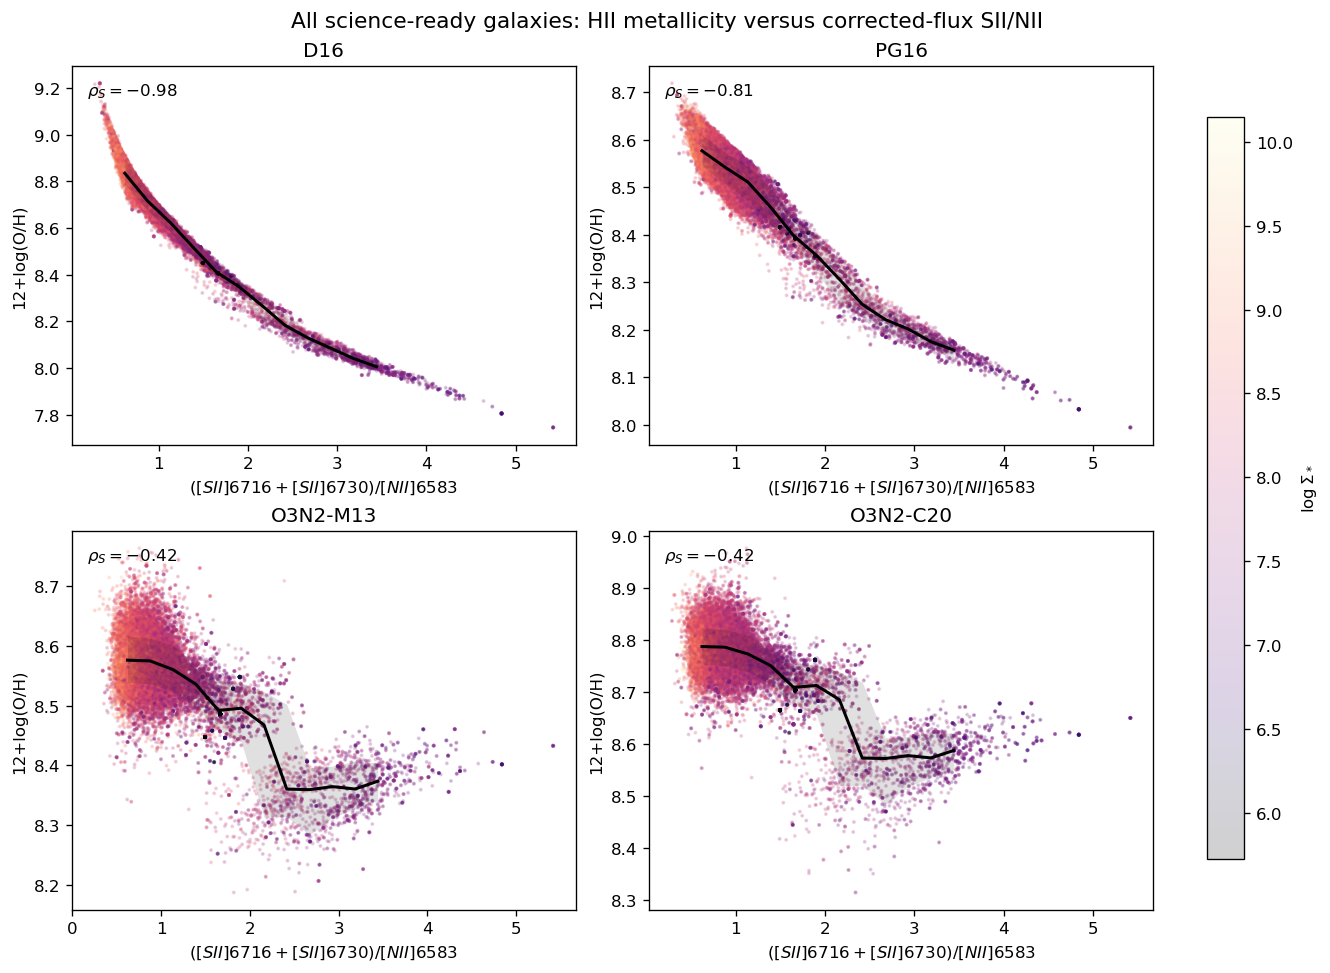

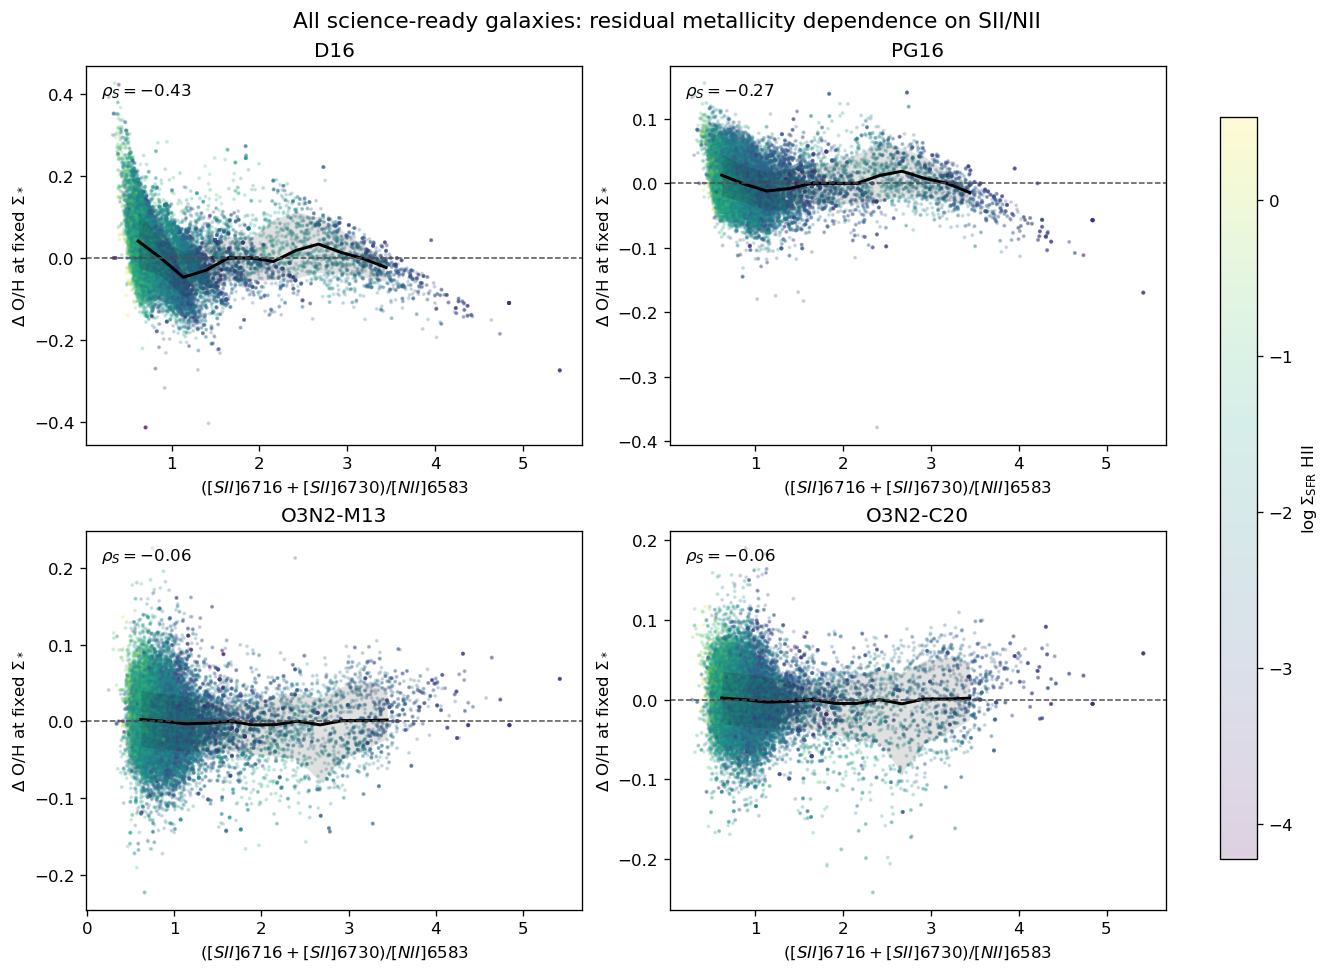

In [8]:

def collect_all_metallicity_s2n2_by_method(galaxies=SCIENCE_READY_GALAXIES):
    payload = {label: [] for _, label in METALLICITY_SPECS}
    counts = []
    for galaxy in galaxies:
        gas_path = further_gas_path(galaxy)
        spatial_path = further_spatial_path(galaxy)
        ratio = corrected_sii_nii_maps(galaxy)["ratio"]
        mass = read_hdu(spatial_path, "LOGMASS_SURFACE_DENSITY")
        logsfr = read_hdu(gas_path, "LOGSFR_SURFACE_DENSITY_HII")

        for hdu_name, label in METALLICITY_SPECS:
            oh = read_hdu(gas_path, hdu_name, required=False)
            if oh is None:
                continue
            ratio_here = align_map_to_shape(ratio, oh.shape, label=f"{galaxy} SII/NII for {label}")
            mass_here = align_map_to_shape(mass, oh.shape, label=f"{galaxy} mass for {label}")
            logsfr_here = align_map_to_shape(logsfr, oh.shape, label=f"{galaxy} logsfr for {label}")
            ok = np.isfinite(ratio_here) & np.isfinite(oh) & np.isfinite(mass_here)
            residual = residual_by_mass_bins(mass_here, oh, ok, n_bins=12)
            ok = ok & np.isfinite(residual)
            counts.append({"galaxy": galaxy, "method": label, "pixels": int(np.sum(ok))})
            if not np.any(ok):
                continue
            payload[label].append(pd.DataFrame({
                "sii_nii": ratio_here[ok],
                "oh": oh[ok],
                "oh_resid_massbin": residual[ok],
                "logmass_surface_density": mass_here[ok],
                "logsfr_surface_density_hii": logsfr_here[ok],
            }))

    combined = {
        label: (pd.concat(frames, ignore_index=True) if frames else pd.DataFrame())
        for label, frames in payload.items()
    }
    return combined, pd.DataFrame(counts)


ALL_METALLICITY_S2N2_BY_METHOD, ALL_METALLICITY_COUNTS = collect_all_metallicity_s2n2_by_method()
display(ALL_METALLICITY_COUNTS.pivot_table(index="galaxy", columns="method", values="pixels", fill_value=0).astype(int))

all_summary_rows = []
for label, frame in ALL_METALLICITY_S2N2_BY_METHOD.items():
    if frame.empty:
        continue
    rho_raw, p_raw = spearmanr(frame["sii_nii"], frame["oh"], nan_policy="omit")
    rho_res, p_res = spearmanr(frame["sii_nii"], frame["oh_resid_massbin"], nan_policy="omit")
    all_summary_rows.append({
        "method": label,
        "n_pixels": len(frame),
        "n_galaxies": int((ALL_METALLICITY_COUNTS.query("method == @label")["pixels"] > 0).sum()),
        "rho(SII/NII, O/H)": rho_raw,
        "p_raw": p_raw,
        "rho(SII/NII, O/H residual at fixed Sigma*)": rho_res,
        "p_residual": p_res,
        "SII/NII_p16": np.nanpercentile(frame["sii_nii"], 16),
        "SII/NII_p50": np.nanpercentile(frame["sii_nii"], 50),
        "SII/NII_p84": np.nanpercentile(frame["sii_nii"], 84),
    })
ALL_S2N2_CORRELATION_SUMMARY = pd.DataFrame(all_summary_rows)
display(ALL_S2N2_CORRELATION_SUMMARY.round(4))


def sample_frame(frame, max_points=30000, seed=20260529):
    if len(frame) <= max_points:
        return frame
    return frame.sample(n=max_points, random_state=seed)


fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
axes = axes.ravel()
for ax, (hdu_name, label) in zip(axes, METALLICITY_SPECS):
    frame = ALL_METALLICITY_S2N2_BY_METHOD[label]
    sample = sample_frame(frame)
    sc = ax.scatter(
        sample["sii_nii"], sample["oh"], c=sample["logmass_surface_density"],
        s=2, alpha=0.18, cmap="magma", rasterized=True,
    )
    centers, med, lo, hi = binned_median_track(frame["sii_nii"].to_numpy(), frame["oh"].to_numpy(), min_count=200)
    if len(centers):
        ax.plot(centers, med, color="black", lw=1.8)
        ax.fill_between(centers, lo, hi, color="black", alpha=0.12, lw=0)
    rho = ALL_S2N2_CORRELATION_SUMMARY.loc[ALL_S2N2_CORRELATION_SUMMARY["method"] == label, "rho(SII/NII, O/H)"].iloc[0]
    ax.text(0.03, 0.96, rf"$\rho_S={rho:.2f}$", transform=ax.transAxes, ha="left", va="top")
    ax.set_title(label)
    ax.set_xlabel(r"$([SII]6716+[SII]6730)/[NII]6583$")
    ax.set_ylabel(r"12+log(O/H)")
fig.colorbar(sc, ax=axes.tolist(), label=r"$\log\Sigma_*$", shrink=0.88)
fig.suptitle("All science-ready galaxies: HII metallicity versus corrected-flux SII/NII", fontsize=13)
# fig.savefig(OUTDIR / "all_galaxies_metallicity_vs_SII_NII.png", dpi=300, bbox_inches="tight")
plt.show()


fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
axes = axes.ravel()
for ax, (hdu_name, label) in zip(axes, METALLICITY_SPECS):
    frame = ALL_METALLICITY_S2N2_BY_METHOD[label]
    sample = sample_frame(frame)
    sc = ax.scatter(
        sample["sii_nii"], sample["oh_resid_massbin"], c=sample["logsfr_surface_density_hii"],
        s=2, alpha=0.18, cmap="viridis", rasterized=True,
    )
    centers, med, lo, hi = binned_median_track(frame["sii_nii"].to_numpy(), frame["oh_resid_massbin"].to_numpy(), min_count=200)
    if len(centers):
        ax.plot(centers, med, color="black", lw=1.8)
        ax.fill_between(centers, lo, hi, color="black", alpha=0.12, lw=0)
    rho = ALL_S2N2_CORRELATION_SUMMARY.loc[
        ALL_S2N2_CORRELATION_SUMMARY["method"] == label,
        "rho(SII/NII, O/H residual at fixed Sigma*)",
    ].iloc[0]
    ax.axhline(0, color="0.3", lw=0.9, ls="--")
    ax.text(0.03, 0.96, rf"$\rho_S={rho:.2f}$", transform=ax.transAxes, ha="left", va="top")
    ax.set_title(label)
    ax.set_xlabel(r"$([SII]6716+[SII]6730)/[NII]6583$")
    ax.set_ylabel(r"$\Delta$ O/H at fixed $\Sigma_*$")
fig.colorbar(sc, ax=axes.tolist(), label=r"$\log\Sigma_{\rm SFR}$ HII", shrink=0.88)
fig.suptitle("All science-ready galaxies: residual metallicity dependence on SII/NII", fontsize=13)
# fig.savefig(OUTDIR / "all_galaxies_metallicity_residual_vs_SII_NII.png", dpi=300, bbox_inches="tight")
plt.show()


## All science-ready HII data: density, Te-metallicity, and low-ionization context

This 2x2 check keeps the same linear SII/NII x-axis and tests four quantities:

- `NE_SII`: electron density from the [S II] doublet, plotted as `log10(ne)` because the density range is broad;
- `O_H_NII_OII7325_HII`: semi-direct NII+OII7325 oxygen abundance;
- `O_H_NII_K25_HII`: NII-only Te proxy oxygen abundance;
- `[SII]/Halpha`: a low-ionization/DIG-sensitive context ratio from corrected total fluxes.

quantity,NE_SII,NII+OII7325 HII,NII-K25 HII,[SII]/Halpha
galaxy,,,,
IC3392,19588,11,0,53760
NGC4064,21757,2,212,82885
NGC4189,131952,279,56,159160
NGC4192,363984,718,517,436254
NGC4293,9896,0,0,26026
NGC4294,132146,1669,1362,178396
NGC4351,51508,195,177,109513
NGC4394,36997,0,0,104170
NGC4402,93951,5,0,197455


,quantity,n_pixels,"rho(SII/NII, quantity)",p_value,SII/NII_p16,SII/NII_p50,SII/NII_p84
0,NE_SII,1943735,-0.0967,0.0,0.6827,0.9146,1.3418
1,NII+OII7325 HII,3324,-0.2764,0.0,0.6157,1.4365,2.1465
2,NII-K25 HII,3502,0.0729,0.0,0.5651,0.8452,2.0430
3,[SII]/Halpha,2950205,0.5158,0.0,0.6749,0.9104,1.4116


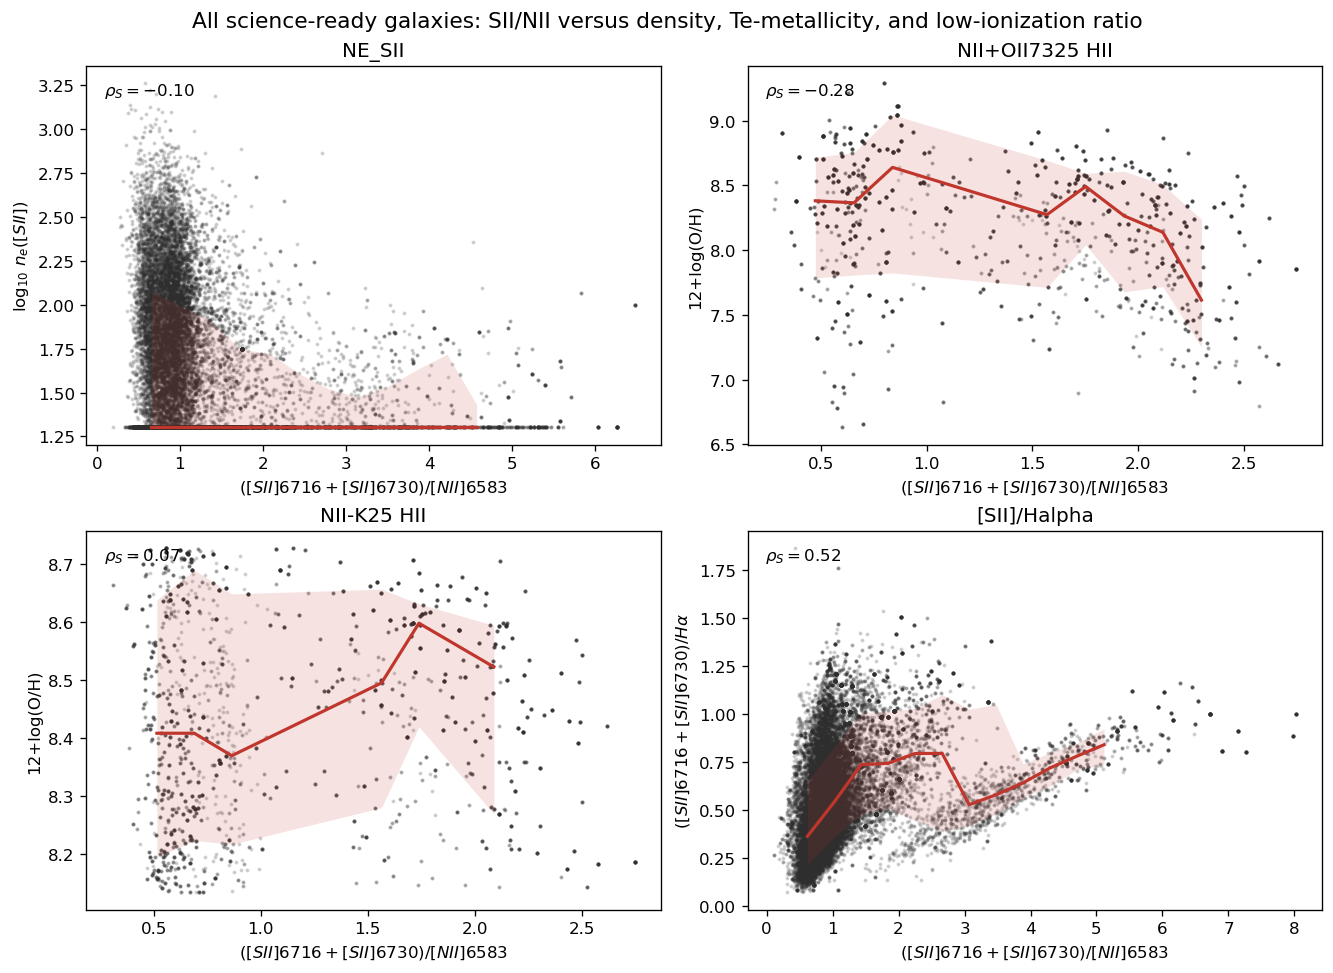

In [9]:

CONTEXT_S2N2_SPECS = [
    {
        "key": "NE_SII",
        "label": r"$\log_{10}\,n_e([SII])$",
        "title": "NE_SII",
        "kind": "hdu",
        "hdu": "NE_SII",
        "transform": "log10_positive",
    },
    {
        "key": "O_H_NII_OII7325_HII",
        "label": r"12+log(O/H)",
        "title": "NII+OII7325 HII",
        "kind": "hdu",
        "hdu": "O_H_NII_OII7325_HII",
        "transform": "identity",
    },
    {
        "key": "O_H_NII_K25_HII",
        "label": r"12+log(O/H)",
        "title": "NII-K25 HII",
        "kind": "hdu",
        "hdu": "O_H_NII_K25_HII",
        "transform": "identity",
    },
    {
        "key": "SII_HA",
        "label": r"$([SII]6716+[SII]6730)/H\alpha$",
        "title": "[SII]/Halpha",
        "kind": "ratio",
        "ratio_name": "sii_ha",
        "transform": "identity",
    },
]


def transform_context_values(values, transform):
    values = np.asarray(values, dtype=float)
    if transform == "identity":
        return values
    if transform == "log10_positive":
        out = np.full(values.shape, np.nan, dtype=float)
        ok = np.isfinite(values) & (values > 0)
        out[ok] = np.log10(values[ok])
        return out
    raise ValueError(f"Unknown transform: {transform}")


def collect_context_s2n2_by_quantity(galaxies=SCIENCE_READY_GALAXIES):
    payload = {spec["key"]: [] for spec in CONTEXT_S2N2_SPECS}
    counts = []
    for galaxy in galaxies:
        gas_path = further_gas_path(galaxy)
        ratio_maps = corrected_sii_nii_maps(galaxy)
        ratio = ratio_maps["ratio"]
        for spec in CONTEXT_S2N2_SPECS:
            if spec["kind"] == "hdu":
                raw_y = read_hdu(gas_path, spec["hdu"], required=False)
                if raw_y is None:
                    counts.append({"galaxy": galaxy, "quantity": spec["title"], "pixels": 0})
                    continue
            else:
                raw_y = ratio_maps[spec["ratio_name"]]
            y = transform_context_values(raw_y, spec["transform"])
            ratio_here = align_map_to_shape(ratio, y.shape, label=f"{galaxy} SII/NII for {spec['title']}")
            ok = np.isfinite(ratio_here) & np.isfinite(y)
            counts.append({"galaxy": galaxy, "quantity": spec["title"], "pixels": int(np.sum(ok))})
            if not np.any(ok):
                continue
            payload[spec["key"]].append(pd.DataFrame({
                "sii_nii": ratio_here[ok],
                "y": y[ok],
            }))
    combined = {
        spec["key"]: (pd.concat(payload[spec["key"]], ignore_index=True) if payload[spec["key"]] else pd.DataFrame())
        for spec in CONTEXT_S2N2_SPECS
    }
    return combined, pd.DataFrame(counts)


CONTEXT_S2N2_BY_QUANTITY, CONTEXT_S2N2_COUNTS = collect_context_s2n2_by_quantity()
display(CONTEXT_S2N2_COUNTS.pivot_table(index="galaxy", columns="quantity", values="pixels", fill_value=0).astype(int))

context_summary_rows = []
for spec in CONTEXT_S2N2_SPECS:
    frame = CONTEXT_S2N2_BY_QUANTITY[spec["key"]]
    if frame.empty:
        continue
    rho, pval = spearmanr(frame["sii_nii"], frame["y"], nan_policy="omit")
    context_summary_rows.append({
        "quantity": spec["title"],
        "n_pixels": len(frame),
        "rho(SII/NII, quantity)": rho,
        "p_value": pval,
        "SII/NII_p16": np.nanpercentile(frame["sii_nii"], 16),
        "SII/NII_p50": np.nanpercentile(frame["sii_nii"], 50),
        "SII/NII_p84": np.nanpercentile(frame["sii_nii"], 84),
    })
CONTEXT_S2N2_SUMMARY = pd.DataFrame(context_summary_rows)
display(CONTEXT_S2N2_SUMMARY.round(4))


fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
axes = axes.ravel()
for ax, spec in zip(axes, CONTEXT_S2N2_SPECS):
    frame = CONTEXT_S2N2_BY_QUANTITY[spec["key"]]
    sample = sample_frame(frame, max_points=30000)
    ax.scatter(sample["sii_nii"], sample["y"], s=2, alpha=0.16, color="0.18", rasterized=True)
    centers, med, lo, hi = binned_median_track(frame["sii_nii"].to_numpy(), frame["y"].to_numpy(), min_count=200)
    if len(centers):
        ax.plot(centers, med, color="#c0362c", lw=1.9)
        ax.fill_between(centers, lo, hi, color="#c0362c", alpha=0.14, lw=0)
    rho = CONTEXT_S2N2_SUMMARY.loc[CONTEXT_S2N2_SUMMARY["quantity"] == spec["title"], "rho(SII/NII, quantity)"].iloc[0]
    ax.text(0.03, 0.96, rf"$\rho_S={rho:.2f}$", transform=ax.transAxes, ha="left", va="top")
    ax.set_title(spec["title"])
    ax.set_xlabel(r"$([SII]6716+[SII]6730)/[NII]6583$")
    ax.set_ylabel(spec["label"])
fig.suptitle("All science-ready galaxies: SII/NII versus density, Te-metallicity, and low-ionization ratio", fontsize=13)
# fig.savefig(OUTDIR / "all_galaxies_te_context_vs_SII_NII.png", dpi=300, bbox_inches="tight")
plt.show()
